> Panduan menggunakan Notebook ini:
> - Jalankan cell 1 (Pip install), kemudian setelah instalasi selesai, ubah kembali cell 1 menjadi bentuk comment.
> - kemudian lakukan "restart & clear cell output"
> - kemudian dapat dilakukan "Run All"

In [60]:
'''
!pip install -q --upgrade --force-reinstall \
    "numpy==1.26.4" \
    "scipy==1.13.1" \
    "scikit-learn==1.5.2" \
    "vus==0.0.6" 
'''

'\n!pip install -q --upgrade --force-reinstall     "numpy==1.26.4"     "scipy==1.13.1"     "scikit-learn==1.5.2"     "vus==0.0.6" \n'

In [61]:
#!pip list

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
import random
import json
from vus.metrics import get_metrics
from pathlib import Path
from itertools import product
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [63]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA device count: 2
GPU name: Tesla T4


# Dataset Loading

In [64]:
data_dir = Path("/kaggle/input/datasets/hoodnerd/pm25-2123")

train_df = pd.read_csv(data_dir / "pm25_2021_2023_train_clean.csv", parse_dates=["datetime"])
val_df   = pd.read_csv(data_dir / "pm25_2021_2023_val_clean.csv", parse_dates=["datetime"])
test_df  = pd.read_csv(data_dir / "pm25_2021_2023_test_clean.csv", parse_dates=["datetime"])

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print(train_df.columns)

Train: (32112, 24)
Val  : (10176, 24)
Test : (10272, 24)
Index(['datetime', 'pm25', 'year_file', 'month_file', 'source_file',
       'is_missing_timestamp', 'label_original', 'label_eval',
       'missing_run_id', 'missing_run_len', 'is_long_gap', 'flat_run_id',
       'flat_run_len', 'flat_pos_in_run', 'is_zero_flatline',
       'is_nonzero_flatline', 'is_long_flatline', 'is_extreme_high_pm25',
       'pm25_clean', 'is_nonzero_flatline_tail_removed', 'label_eval_clean',
       'is_invalid_pm25', 'year', 'month'],
      dtype='str')


In [65]:
for name, df_split in {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df
}.items():
    print("=" * 60)
    print(name)
    print("Index start:", df_split.index.min())
    print("Index end  :", df_split.index.max())
    print("Length     :", len(df_split))
    print("Is monotonic increasing:", df_split.index.is_monotonic_increasing)
    print("Is default RangeIndex  :", isinstance(df_split.index, pd.RangeIndex))
    print()

required_cols = [
    "datetime",
    "pm25",
    "pm25_clean",
    "label_eval_clean",
    "is_missing_timestamp",
    "missing_run_len"
]

for name, df_split in {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df
}.items():
    missing_cols = [c for c in required_cols if c not in df_split.columns]
    print(name, "missing required cols:", missing_cols)

train_df
Index start: 0
Index end  : 32111
Length     : 32112
Is monotonic increasing: True
Is default RangeIndex  : True

val_df
Index start: 0
Index end  : 10175
Length     : 10176
Is monotonic increasing: True
Is default RangeIndex  : True

test_df
Index start: 0
Index end  : 10271
Length     : 10272
Is monotonic increasing: True
Is default RangeIndex  : True

train_df missing required cols: []
val_df missing required cols: []
test_df missing required cols: []


# Interpolation

In [66]:
SHORT_GAP_LIMIT = 12

def interpolate_short_gaps_only(df_split, short_gap_limit=12, value_col="pm25_clean"):
    """
    Interpolasi hanya missing timestamp gap pendek.
    
    Sumber nilai yang dipakai adalah pm25_clean, bukan pm25 raw.
    Static zero, extreme high, dan flatline tail yang sudah menjadi NaN
    tidak akan diinterpolasi kecuali ia memang missing timestamp short gap.
    """
    df_split = df_split.copy()
    df_split["datetime"] = pd.to_datetime(df_split["datetime"])
    df_split = df_split.sort_values("datetime").reset_index(drop=True)

    tmp = df_split.set_index("datetime").copy()

    interp_time = tmp[value_col].interpolate(
        method="time",
        limit_direction="both",
        limit_area="inside"
    )

    interp_pos = pd.Series(
        interp_time.to_numpy(),
        index=df_split.index
    )

    df_split["pm25_interp"] = df_split[value_col]

    short_gap_mask = (
        (df_split["is_missing_timestamp"] == 1) &
        (df_split["missing_run_len"] <= short_gap_limit)
    )

    df_split.loc[short_gap_mask, "pm25_interp"] = interp_pos.loc[short_gap_mask]

    return df_split

In [67]:
train_df = interpolate_short_gaps_only(train_df, SHORT_GAP_LIMIT, value_col="pm25_clean")
val_df   = interpolate_short_gaps_only(val_df, SHORT_GAP_LIMIT, value_col="pm25_clean")

print("NaN after interpolation:")
print("Train:", train_df["pm25_interp"].isna().sum())
print("Val  :", val_df["pm25_interp"].isna().sum())

NaN after interpolation:
Train: 1549
Val  : 125


In [68]:
def check_interpolation_result(df, name):
    short_gap_mask = (
        (df["is_missing_timestamp"] == 1) &
        (df["missing_run_len"] <= SHORT_GAP_LIMIT)
    )

    long_gap_mask = (
        (df["is_missing_timestamp"] == 1) &
        (df["missing_run_len"] > SHORT_GAP_LIMIT)
    )

    observed_clean_mask = (
        (df["is_missing_timestamp"] == 0) &
        df["pm25_clean"].notna()
    )

    observed_unchanged = np.allclose(
        df.loc[observed_clean_mask, "pm25_clean"],
        df.loc[observed_clean_mask, "pm25_interp"],
        equal_nan=True
    )

    print("=" * 60)
    print(name)
    print("Observed clean unchanged:", observed_unchanged)
    print("Short gap points:", short_gap_mask.sum())
    print("Short gap still NaN:", df.loc[short_gap_mask, "pm25_interp"].isna().sum())
    print("Long gap points:", long_gap_mask.sum())
    print("Long gap filled:", df.loc[long_gap_mask, "pm25_interp"].notna().sum())
    print("Total NaN pm25_clean:", df["pm25_clean"].isna().sum())
    print("Total NaN pm25_interp:", df["pm25_interp"].isna().sum())

In [69]:
check_interpolation_result(train_df, "Train")
check_interpolation_result(val_df, "Val")

Train
Observed clean unchanged: True
Short gap points: 185
Short gap still NaN: 0
Long gap points: 1100
Long gap filled: 0
Total NaN pm25_clean: 1734
Total NaN pm25_interp: 1549
Val
Observed clean unchanged: True
Short gap points: 13
Short gap still NaN: 0
Long gap points: 94
Long gap filled: 0
Total NaN pm25_clean: 138
Total NaN pm25_interp: 125


In [70]:
def finalize_clean_split(df, clean_col="pm25_clean", interp_col="pm25_interp", use_interpolation=True):
    df = df.copy()

    if use_interpolation:
        df["pm25_model"] = df[interp_col]

        df["is_interpolated"] = (
            (df["is_missing_timestamp"] == 1) &
            df[clean_col].isna() &
            df[interp_col].notna()
        ).astype(int)

    else:
        df["pm25_model"] = df[clean_col]
        df["is_interpolated"] = 0

    df["usable_point"] = df["pm25_model"].notna().astype(int)

    return df

train_df = finalize_clean_split(
    train_df,
    use_interpolation=True
)

val_df = finalize_clean_split(
    val_df,
    use_interpolation=True
)

test_df = finalize_clean_split(
    test_df,
    use_interpolation=False
)

In [71]:
'''
EXTREME_LIMIT = 233.0

def apply_extreme_limit(df, name, limit=EXTREME_LIMIT):
    mask = df["pm25_model"] > limit
    n_removed = int(mask.sum())
    n_anom = int((df.loc[mask, "label_eval_clean"] == 1).sum())
    n_norm = int((df.loc[mask, "label_eval_clean"] == 0).sum())
    print(f"{name}: removed {n_removed} points (anomali={n_anom}, normal={n_norm})")

    # ubah nilai model DAN label jadi NaN
    df.loc[mask, ["pm25_model", "label_eval_clean"]] = np.nan
    df["usable_point"] = df["pm25_model"].notna().astype(int)
    return df

# Terapkan HANYA di train dan val (test tidak)
train_df = apply_extreme_limit(train_df, "Train")
val_df   = apply_extreme_limit(val_df, "Val")

print("\nTrain PM2.5 max:", train_df["pm25_model"].max())
print("Val PM2.5 max  :", val_df["pm25_model"].max())
print("Test PM2.5 max :", test_df["pm25_model"].max())
'''


Train: removed 1 points (anomali=1, normal=0)
Val: removed 19 points (anomali=19, normal=0)

Train PM2.5 max: 230.0
Val PM2.5 max  : 233.0
Test PM2.5 max : 283.0


In [72]:
print("\nTrain PM2.5 max:", train_df["pm25_model"].max())
print("Val PM2.5 max  :", val_df["pm25_model"].max())
print("Test PM2.5 max :", test_df["pm25_model"].max())


Train PM2.5 max: 230.0
Val PM2.5 max  : 233.0
Test PM2.5 max : 283.0


In [73]:
def check_interpolation_summary(df, name):
    print(f"=== {name} ===")
    print("Rows:", len(df))
    print("Missing timestamp:", df["is_missing_timestamp"].sum())
    print("Short-gap missing:", ((df["is_missing_timestamp"] == 1) & (df["missing_run_len"] <= SHORT_GAP_LIMIT)).sum())
    print("Long-gap missing :", ((df["is_missing_timestamp"] == 1) & (df["missing_run_len"] > SHORT_GAP_LIMIT)).sum())
    print("NaN pm25 original:", df["pm25"].isna().sum())
    print("NaN pm25_clean   :", df["pm25_clean"].isna().sum())
    print("NaN pm25_model   :", df["pm25_model"].isna().sum())
    print("Interpolated     :", df["is_interpolated"].sum())
    print()

check_interpolation_summary(train_df, "Train")
check_interpolation_summary(val_df, "Val")
check_interpolation_summary(test_df, "Test")

=== Train ===
Rows: 32112
Missing timestamp: 1285
Short-gap missing: 185
Long-gap missing : 1100
NaN pm25 original: 1285
NaN pm25_clean   : 1734
NaN pm25_model   : 1550
Interpolated     : 185

=== Val ===
Rows: 10176
Missing timestamp: 107
Short-gap missing: 13
Long-gap missing : 94
NaN pm25 original: 107
NaN pm25_clean   : 138
NaN pm25_model   : 144
Interpolated     : 13

=== Test ===
Rows: 10272
Missing timestamp: 198
Short-gap missing: 20
Long-gap missing : 178
NaN pm25 original: 198
NaN pm25_clean   : 252
NaN pm25_model   : 252
Interpolated     : 0



In [74]:
def check_observed_value_unchanged(df, name):
    observed_value_mask = (
        (df["is_missing_timestamp"] == 0) &
        (df["pm25_clean"].notna())
    )

    unchanged = np.allclose(
        df.loc[observed_value_mask, "pm25_clean"].values,
        df.loc[observed_value_mask, "pm25_model"].values,
        equal_nan=True
    )

    print(f"{name} observed clean values unchanged:", unchanged)

check_observed_value_unchanged(train_df, "Train")
check_observed_value_unchanged(val_df, "Val")
check_observed_value_unchanged(test_df, "Test")

Train observed clean values unchanged: False
Val observed clean values unchanged: False
Test observed clean values unchanged: True


In [75]:
def check_short_gap_filled(df, name):
    short_gap_mask = (
        (df["is_missing_timestamp"] == 1) &
        (df["missing_run_len"] <= SHORT_GAP_LIMIT)
    )
    
    print(f"=== {name} short gap ===")
    print("Short-gap points:", short_gap_mask.sum())
    print("Still NaN after interpolation:", df.loc[short_gap_mask, "pm25_interp"].isna().sum())
    print(df.loc[short_gap_mask, ["datetime", "pm25_clean", "pm25_interp","pm25_model",  "missing_run_len"]].head(10))
    print()

check_short_gap_filled(train_df, "Train")
check_short_gap_filled(val_df, "Val")

=== Train short gap ===
Short-gap points: 185
Still NaN after interpolation: 0
                datetime  pm25_clean  pm25_interp  pm25_model  missing_run_len
2422 2021-02-20 11:00:00         NaN    10.333333   10.333333                2
2423 2021-02-20 11:30:00         NaN    10.666667   10.666667                2
2617 2021-02-24 12:30:00         NaN     4.000000    4.000000                3
2618 2021-02-24 13:00:00         NaN     4.000000    4.000000                3
2619 2021-02-24 13:30:00         NaN     4.000000    4.000000                3
2621 2021-02-24 14:30:00         NaN     7.000000    7.000000                1
5020 2021-04-15 14:00:00         NaN    84.000000   84.000000                1
5796 2021-05-01 18:00:00         NaN    10.500000   10.500000                1
6954 2021-05-25 21:00:00         NaN    43.500000   43.500000                1
8569 2021-06-28 12:30:00         NaN    62.500000   62.500000                1

=== Val short gap ===
Short-gap points: 13
Still Na

In [76]:
def check_long_gap_remains_nan(df, name):
    long_gap_mask = (
        (df["is_missing_timestamp"] == 1) &
        (df["missing_run_len"] > SHORT_GAP_LIMIT)
    )
    
    print(f"=== {name} long gap ===")
    print("Long-gap points:", long_gap_mask.sum())
    print("Non-NaN after interpolation:", df.loc[long_gap_mask, "pm25_model"].notna().sum())
    print(df.loc[long_gap_mask, ["datetime", "pm25_clean", "pm25_interp", "pm25_model", "missing_run_len"]].head(10))
    print()

check_long_gap_remains_nan(train_df, "Train")
check_long_gap_remains_nan(val_df, "Val")

=== Train long gap ===
Long-gap points: 1100
Non-NaN after interpolation: 0
                datetime  pm25_clean  pm25_interp  pm25_model  missing_run_len
1035 2021-01-22 13:30:00         NaN          NaN         NaN               46
1036 2021-01-22 14:00:00         NaN          NaN         NaN               46
1037 2021-01-22 14:30:00         NaN          NaN         NaN               46
1038 2021-01-22 15:00:00         NaN          NaN         NaN               46
1039 2021-01-22 15:30:00         NaN          NaN         NaN               46
1040 2021-01-22 16:00:00         NaN          NaN         NaN               46
1041 2021-01-22 16:30:00         NaN          NaN         NaN               46
1042 2021-01-22 17:00:00         NaN          NaN         NaN               46
1043 2021-01-22 17:30:00         NaN          NaN         NaN               46
1044 2021-01-22 18:00:00         NaN          NaN         NaN               46

=== Val long gap ===
Long-gap points: 94
Non-NaN after

In [77]:
def plot_missing_run_by_id(df_split, run_id, hours_before=6, hours_after=6):
    run_points = df_split[df_split["missing_run_id"] == run_id].copy()

    if run_points.empty:
        print(f"missing_run_id {run_id} tidak ditemukan.")
        return

    gap_start = run_points["datetime"].min()
    gap_end = run_points["datetime"].max()

    start = gap_start - pd.Timedelta(hours=hours_before)
    end = gap_end + pd.Timedelta(hours=hours_after)

    df_plot = df_split[
        (df_split["datetime"] >= start) &
        (df_split["datetime"] <= end)
    ].copy()

    plt.figure(figsize=(16, 4))

    plt.plot(
        df_plot["datetime"],
        df_plot["pm25_clean"],
        marker="o",
        linewidth=1,
        label="PM2.5 clean"
    )

    plt.plot(
        df_plot["datetime"],
        df_plot["pm25_model"],
        marker="x",
        linewidth=1,
        label="PM2.5 model"
    )

    gap_plot = df_plot[df_plot["missing_run_id"] == run_id]

    plt.scatter(
        gap_plot["datetime"],
        gap_plot["pm25_interp"],
        s=80,
        label=f"Missing run {run_id}",
        zorder=3
    )

    gap_type = "short gap filled" if run_points["missing_run_len"].max() <= SHORT_GAP_LIMIT else "long gap remains NaN"

    plt.axvspan(gap_start, gap_end, alpha=0.15)

    plt.title(
        f"Missing Run ID {run_id} | {gap_type} | "
        f"{len(run_points)} points / {len(run_points)*0.5:.1f} hours"
    )
    plt.xlabel("Datetime")
    plt.ylabel("PM2.5_model")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

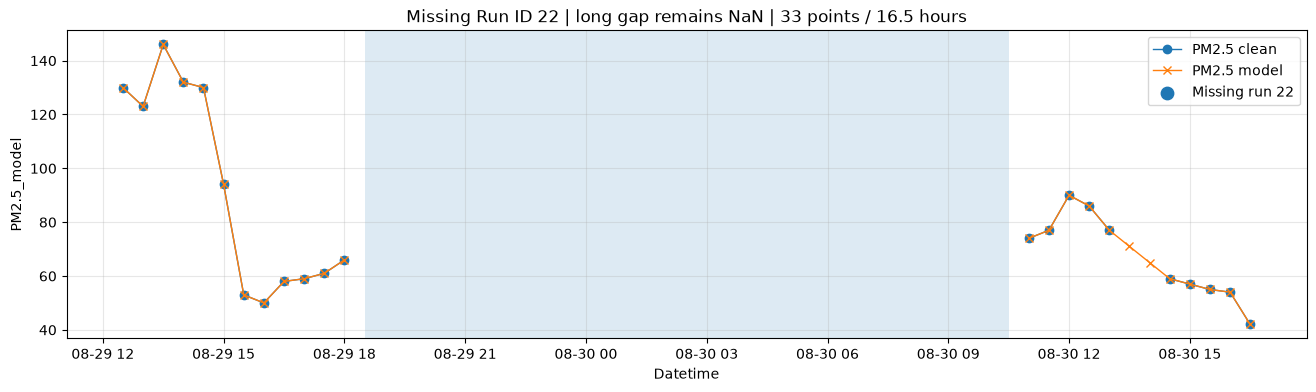

In [78]:
plot_missing_run_by_id(train_df, run_id=22)

In [79]:
for name, df_split in {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df
}.items():
    print("=" * 60)
    print(name)
    print("Rows:", len(df_split))
    print("NaN pm25 original :", df_split["pm25"].isna().sum())
    print("NaN pm25_clean    :", df_split["pm25_clean"].isna().sum())
    print("NaN pm25 model :", df_split["pm25_model"].isna().sum())
    print("Interpolated pts  :", df_split["is_interpolated"].sum())
    print("Usable points     :", df_split["usable_point"].sum())
    print()

train_df
Rows: 32112
NaN pm25 original : 1285
NaN pm25_clean    : 1734
NaN pm25 model : 1550
Interpolated pts  : 185
Usable points     : 30562

val_df
Rows: 10176
NaN pm25 original : 107
NaN pm25_clean    : 138
NaN pm25 model : 144
Interpolated pts  : 13
Usable points     : 10032

test_df
Rows: 10272
NaN pm25 original : 198
NaN pm25_clean    : 252
NaN pm25 model : 252
Interpolated pts  : 0
Usable points     : 10020



## Scaling/Normalization

In [80]:
scaler = MinMaxScaler()

train_fit_values = train_df.loc[
    train_df["pm25_model"].notna(),
    ["pm25_model"]
]

scaler.fit(train_fit_values)

train_df["pm25_scaled"] = scaler.transform(train_df[["pm25_model"]])
val_df["pm25_scaled"]   = scaler.transform(val_df[["pm25_model"]])
test_df["pm25_scaled"]  = scaler.transform(test_df[["pm25_model"]])

print("Train PM2.5 min:", scaler.data_min_[0])
print("Train PM2.5 max:", scaler.data_max_[0])

print()
print("Train scaled min/max:", train_df["pm25_scaled"].min(), train_df["pm25_scaled"].max())
print("Val scaled min/max  :", val_df["pm25_scaled"].min(), val_df["pm25_scaled"].max())
print("Test scaled min/max :", test_df["pm25_scaled"].min(), test_df["pm25_scaled"].max())

print()
print("NaN scaled train:", train_df["pm25_scaled"].isna().sum())
print("NaN scaled val  :", val_df["pm25_scaled"].isna().sum())
print("NaN scaled test :", test_df["pm25_scaled"].isna().sum())

Train PM2.5 min: 0.0
Train PM2.5 max: 230.0

Train scaled min/max: 0.0 1.0
Val scaled min/max  : 0.0 1.0130434782608695
Test scaled min/max : 0.0 1.2304347826086957

NaN scaled train: 1550
NaN scaled val  : 144
NaN scaled test : 252


# Windowing

In [81]:
def create_windows(
    df_split,
    value_col="pm25_scaled",
    interp_col="is_interpolated",
    datetime_col="datetime",
    window_size=100,
    max_interp_ratio=0.10,
    strict_less=True
):
    """
    Window valid jika:
    1. tidak mengandung NaN pada value_col
    2. jumlah interpolated points < max_interp_ratio * window_size
       jika strict_less=True
    """

    df_split = df_split.sort_values(datetime_col).reset_index(drop=True).copy()

    values = df_split[value_col].values.astype(np.float32)
    interp_flags = df_split[interp_col].values.astype(int)

    L = window_size
    max_interp_points = max_interp_ratio * L

    X_list = []
    valid_info_rows = []
    all_info_rows = []

    for i in range(len(df_split) - L + 1):
        start = i
        end = i + L

        window_values = values[start:end]
        window_interp = interp_flags[start:end]

        has_nan = np.isnan(window_values).any()
        n_interpolated = int(window_interp.sum())
        interp_ratio = n_interpolated / L

        if strict_less:
            interp_ok = n_interpolated < max_interp_points
        else:
            interp_ok = n_interpolated <= max_interp_points

        is_valid = (not has_nan) and interp_ok

        info = {
            "window_idx": i,
            "window_start_datetime": df_split.loc[start, datetime_col],
            "window_end_datetime": df_split.loc[end - 1, datetime_col],
            "has_nan": int(has_nan),
            "n_interpolated_points": n_interpolated,
            "interp_ratio": interp_ratio,
            "is_valid_window": int(is_valid)
        }

        all_info_rows.append(info)

        if is_valid:
            X_list.append(window_values)
            valid_info_rows.append(info)

    X_valid = np.array(X_list, dtype=np.float32)

    if len(X_valid) > 0:
        X_valid = X_valid[:, None, :]
    else:
        X_valid = np.empty((0, 1, L), dtype=np.float32)

    window_info_valid = pd.DataFrame(valid_info_rows)
    all_window_info = pd.DataFrame(all_info_rows)

    return X_valid, window_info_valid, all_window_info

In [82]:
L = 48
max_interp_ratio = 0.10

X_train, train_window_info, train_all_window_info = create_windows(
    train_df,
    value_col="pm25_scaled",
    interp_col="is_interpolated",
    datetime_col="datetime",
    window_size=L,
    max_interp_ratio=max_interp_ratio,
    strict_less=True
)

X_val, val_window_info, val_all_window_info = create_windows(
    val_df,
    value_col="pm25_scaled",
    interp_col="is_interpolated",
    datetime_col="datetime",
    window_size=L,
    max_interp_ratio=max_interp_ratio,
    strict_less=True
)

X_test, test_window_info, test_all_window_info = create_windows(
    test_df,
    value_col="pm25_scaled",
    interp_col="is_interpolated",
    datetime_col="datetime",
    window_size=L,
    max_interp_ratio=max_interp_ratio,
    strict_less=True
)

print("L:", L)
print("Max interpolated ratio:", max_interp_ratio)
print()

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

L: 48
Max interpolated ratio: 0.1

X_train: (27123, 1, 48)
X_val  : (8772, 1, 48)
X_test : (9210, 1, 48)


In [83]:
def summarize_window_filtering(all_window_info, name):
    print("=" * 70)
    print(name)
    print("=" * 70)

    n_candidate = len(all_window_info)
    n_valid = all_window_info["is_valid_window"].sum()
    n_dropped = n_candidate - n_valid

    print("Candidate windows:", n_candidate)
    print("Valid windows    :", n_valid)
    print("Dropped windows  :", n_dropped)

    print()
    print("Dropped because has NaN:", (
        (all_window_info["has_nan"] == 1) &
        (all_window_info["is_valid_window"] == 0)
    ).sum())

    print("Dropped because interp >= 10%:", (
        (all_window_info["interp_ratio"] >= max_interp_ratio) &
        (all_window_info["is_valid_window"] == 0)
    ).sum())

    valid_info = all_window_info[all_window_info["is_valid_window"] == 1]

    print()
    print("Interpolated points per valid window:")
    display(valid_info["n_interpolated_points"].describe())


summarize_window_filtering(train_all_window_info, "Train")
summarize_window_filtering(val_all_window_info, "Val")
summarize_window_filtering(test_all_window_info, "Test")

Train
Candidate windows: 32065
Valid windows    : 27123
Dropped windows  : 4942

Dropped because has NaN: 4663
Dropped because interp >= 10%: 427

Interpolated points per valid window:


count    27123.000000
mean         0.064152
std          0.391374
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: n_interpolated_points, dtype: float64

Val
Candidate windows: 10129
Valid windows    : 8772
Dropped windows  : 1357

Dropped because has NaN: 1275
Dropped because interp >= 10%: 90

Interpolated points per valid window:


count    8772.000000
mean        0.008892
std         0.125118
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.000000
Name: n_interpolated_points, dtype: float64

Test
Candidate windows: 10225
Valid windows    : 9210
Dropped windows  : 1015

Dropped because has NaN: 1015
Dropped because interp >= 10%: 0

Interpolated points per valid window:


count    9210.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: n_interpolated_points, dtype: float64

In [84]:
print("X_train has NaN:", np.isnan(X_train).any())
print("X_val has NaN  :", np.isnan(X_val).any())
print("X_test has NaN :", np.isnan(X_test).any())

print()
print("Max interp ratio train valid:", train_window_info["interp_ratio"].max())
print("Max interp ratio val valid  :", val_window_info["interp_ratio"].max())
print("Max interp ratio test valid :", test_window_info["interp_ratio"].max())

X_train has NaN: False
X_val has NaN  : False
X_test has NaN : False

Max interp ratio train valid: 0.08333333333333333
Max interp ratio val valid  : 0.08333333333333333
Max interp ratio test valid : 0.0


## Point to Window Labeling

In [85]:
print("label_eval_clean in test_df:", "label_eval_clean" in test_df.columns)

print("Test anomaly points:", test_df["label_eval_clean"].sum(skipna=True))
print("Test anomaly rate:", test_df["label_eval_clean"].mean(skipna=True))

label_eval_clean in test_df: True
Test anomaly points: 368.0
Test anomaly rate: 0.036726546906187624


In [86]:
def create_window_labels_from_point_labels(
    df_split,
    window_info,
    label_col="label_eval_clean",
    window_size=100,
    datetime_col="datetime"
):
    df_split = df_split.sort_values(datetime_col).reset_index(drop=True).copy()
    window_info_labeled = window_info.copy().reset_index(drop=True)

    point_labels = df_split[label_col].fillna(0).astype(int).values

    y_window = []
    n_anomaly_points = []
    anomaly_point_datetimes = []

    for _, row in window_info_labeled.iterrows():
        start = int(row["window_idx"])
        end = start + window_size

        window_labels = point_labels[start:end]

        n_anom = int(window_labels.sum())
        y = int(n_anom > 0)

        y_window.append(y)
        n_anomaly_points.append(n_anom)

        if n_anom > 0:
            window_slice = df_split.iloc[start:end].copy()
            anomaly_dates = window_slice.loc[
                window_slice[label_col].fillna(0).astype(int) == 1,
                datetime_col
            ].tolist()
        else:
            anomaly_dates = []

        anomaly_point_datetimes.append(anomaly_dates)

    window_info_labeled["y_window"] = y_window
    window_info_labeled["n_anomaly_points"] = n_anomaly_points
    window_info_labeled["anomaly_point_datetimes"] = anomaly_point_datetimes

    return window_info_labeled

In [87]:
test_window_info = create_window_labels_from_point_labels(
    df_split=test_df,
    window_info=test_window_info,
    label_col="label_eval_clean",
    window_size=L,
    datetime_col="datetime"
)

y_test_window = test_window_info["y_window"].values.astype(int)

print("Test valid windows:", len(test_window_info))
print("Test anomaly windows:", y_test_window.sum())
print("Test normal windows:", len(y_test_window) - y_test_window.sum())
print("Test anomaly window rate:", y_test_window.mean())

Test valid windows: 9210
Test anomaly windows: 1627
Test normal windows: 7583
Test anomaly window rate: 0.1766558089033659


In [88]:
display(
    test_window_info[test_window_info["y_window"] == 1][
        [
            "window_idx",
            "window_start_datetime",
            "window_end_datetime",
            "y_window",
            "n_anomaly_points",
            "n_interpolated_points",
            "interp_ratio",
            "anomaly_point_datetimes"
        ]
    ].head(100)
)

,window_idx,window_start_datetime,window_end_datetime,y_window,n_anomaly_points,n_interpolated_points,interp_ratio,anomaly_point_datetimes
192,192,2023-06-05 00:00:00,2023-06-05 23:30:00,1,1,0,0.0,[2023-06-05 23:30:00]
193,193,2023-06-05 00:30:00,2023-06-06 00:00:00,1,2,0,0.0,"[2023-06-05 23:30:00, 2023-06-06 00:00:00]"
194,194,2023-06-05 01:00:00,2023-06-06 00:30:00,1,3,0,0.0,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
195,195,2023-06-05 01:30:00,2023-06-06 01:00:00,1,4,0,0.0,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
196,196,2023-06-05 02:00:00,2023-06-06 01:30:00,1,4,0,0.0,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
...,...,...,...,...,...,...,...,...
466,466,2023-06-10 17:00:00,2023-06-11 16:30:00,1,9,0,0.0,"[2023-06-11 00:30:00, 2023-06-11 02:00:00, 202..."
467,467,2023-06-10 17:30:00,2023-06-11 17:00:00,1,9,0,0.0,"[2023-06-11 00:30:00, 2023-06-11 02:00:00, 202..."
468,468,2023-06-10 18:00:00,2023-06-11 17:30:00,1,9,0,0.0,"[2023-06-11 00:30:00, 2023-06-11 02:00:00, 202..."
469,469,2023-06-10 18:30:00,2023-06-11 18:00:00,1,9,0,0.0,"[2023-06-11 00:30:00, 2023-06-11 02:00:00, 202..."


In [89]:
display(
    test_window_info[
        [
            "window_idx",
            "window_start_datetime",
            "window_end_datetime",
            "y_window",
            "n_anomaly_points",
            "n_interpolated_points",
            "interp_ratio",
            "anomaly_point_datetimes"
        ]
    ].head(1000)
)

,window_idx,window_start_datetime,window_end_datetime,y_window,n_anomaly_points,n_interpolated_points,interp_ratio,anomaly_point_datetimes
0,0,2023-06-01 00:00:00,2023-06-01 23:30:00,0,0,0,0.0,[]
1,1,2023-06-01 00:30:00,2023-06-02 00:00:00,0,0,0,0.0,[]
2,2,2023-06-01 01:00:00,2023-06-02 00:30:00,0,0,0,0.0,[]
3,3,2023-06-01 01:30:00,2023-06-02 01:00:00,0,0,0,0.0,[]
4,4,2023-06-01 02:00:00,2023-06-02 01:30:00,0,0,0,0.0,[]
...,...,...,...,...,...,...,...,...
995,1069,2023-06-23 06:30:00,2023-06-24 06:00:00,1,2,0,0.0,"[2023-06-23 06:30:00, 2023-06-23 07:00:00]"
996,1070,2023-06-23 07:00:00,2023-06-24 06:30:00,1,1,0,0.0,[2023-06-23 07:00:00]
997,1071,2023-06-23 07:30:00,2023-06-24 07:00:00,0,0,0,0.0,[]
998,1072,2023-06-23 08:00:00,2023-06-24 07:30:00,0,0,0,0.0,[]


## Window Anomaly Visualization

In [90]:
# contoh untuk test
test_anom_windows = test_window_info[test_window_info["y_window"] == 1].copy()

print("Jumlah anomaly windows di test:", len(test_anom_windows))
display(test_anom_windows.head(10))

Jumlah anomaly windows di test: 1627


,window_idx,window_start_datetime,window_end_datetime,has_nan,n_interpolated_points,interp_ratio,is_valid_window,y_window,n_anomaly_points,anomaly_point_datetimes
192,192,2023-06-05 00:00:00,2023-06-05 23:30:00,0,0,0.0,1,1,1,[2023-06-05 23:30:00]
193,193,2023-06-05 00:30:00,2023-06-06 00:00:00,0,0,0.0,1,1,2,"[2023-06-05 23:30:00, 2023-06-06 00:00:00]"
194,194,2023-06-05 01:00:00,2023-06-06 00:30:00,0,0,0.0,1,1,3,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
195,195,2023-06-05 01:30:00,2023-06-06 01:00:00,0,0,0.0,1,1,4,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
196,196,2023-06-05 02:00:00,2023-06-06 01:30:00,0,0,0.0,1,1,4,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
197,197,2023-06-05 02:30:00,2023-06-06 02:00:00,0,0,0.0,1,1,4,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
198,198,2023-06-05 03:00:00,2023-06-06 02:30:00,0,0,0.0,1,1,4,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
199,199,2023-06-05 03:30:00,2023-06-06 03:00:00,0,0,0.0,1,1,5,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
200,200,2023-06-05 04:00:00,2023-06-06 03:30:00,0,0,0.0,1,1,5,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."
201,201,2023-06-05 04:30:00,2023-06-06 04:00:00,0,0,0.0,1,1,5,"[2023-06-05 23:30:00, 2023-06-06 00:00:00, 202..."


In [91]:
def plot_single_window(
    df_split,
    window_info_df,
    row_idx,
    datetime_col="datetime",
    value_col="pm25_scaled",
    label_col="label_eval_clean",
    interp_col="is_interpolated",
    figsize=(14, 5)
):
    """
    Plot satu window berdasarkan baris ke-row_idx pada window_info_df.
    
    row_idx = index baris pada window_info_df (bukan window_idx).
    """

    row = window_info_df.iloc[row_idx]

    start_dt = pd.to_datetime(row["window_start_datetime"])
    end_dt   = pd.to_datetime(row["window_end_datetime"])
    y_window = row["y_window"]
    window_idx = row["window_idx"]

    # ambil data window berdasarkan rentang waktu
    win_df = df_split[
        (df_split[datetime_col] >= start_dt) &
        (df_split[datetime_col] <= end_dt)
    ].copy()

    plt.figure(figsize=figsize)
    plt.plot(
        win_df[datetime_col],
        win_df[value_col],
        marker="o",
        label=value_col
    )

    # highlight anomaly point
    anomaly_pts = win_df[win_df[label_col] == 1]
    if len(anomaly_pts) > 0:
        plt.scatter(
            anomaly_pts[datetime_col],
            anomaly_pts[value_col],
            s=90,
            label="Anomaly point"
        )

    # highlight interpolated point (kalau kolom ada)
    if interp_col in win_df.columns:
        interp_pts = win_df[win_df[interp_col] == 1]
        if len(interp_pts) > 0:
            plt.scatter(
                interp_pts[datetime_col],
                interp_pts[value_col],
                s=70,
                marker="x",
                label="Interpolated point"
            )

    plt.title(
        f"Window row={row_idx} | window_idx={window_idx} | "
        f"{start_dt} to {end_dt} | y_window={y_window} | "
        f"n_anomaly_points={row.get('n_anomaly_points', 'NA')}"
    )
    plt.xlabel("Datetime")
    plt.ylabel(value_col)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return win_df

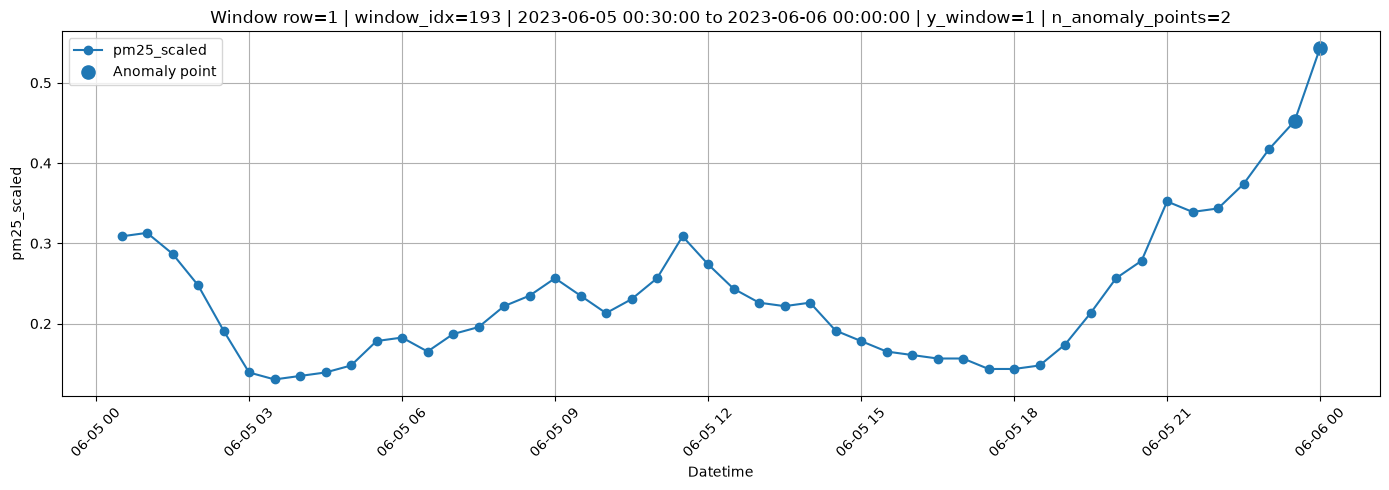

,datetime,pm25,year_file,month_file,source_file,is_missing_timestamp,label_original,label_eval,missing_run_id,missing_run_len,...,pm25_clean,is_nonzero_flatline_tail_removed,label_eval_clean,is_invalid_pm25,year,month,pm25_model,is_interpolated,usable_point,pm25_scaled
193,2023-06-05 00:30:00,71.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,71.0,0,0.0,0,2023,6,71.0,0,1,0.308696
194,2023-06-05 01:00:00,72.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,72.0,0,0.0,0,2023,6,72.0,0,1,0.313043
195,2023-06-05 01:30:00,66.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,66.0,0,0.0,0,2023,6,66.0,0,1,0.286957
196,2023-06-05 02:00:00,57.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,57.0,0,0.0,0,2023,6,57.0,0,1,0.247826
197,2023-06-05 02:30:00,44.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,44.0,0,0.0,0,2023,6,44.0,0,1,0.191304
198,2023-06-05 03:00:00,32.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,32.0,0,0.0,0,2023,6,32.0,0,1,0.139130
199,2023-06-05 03:30:00,30.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,30.0,0,0.0,0,2023,6,30.0,0,1,0.130435
200,2023-06-05 04:00:00,31.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,31.0,0,0.0,0,2023,6,31.0,0,1,0.134783
201,2023-06-05 04:30:00,32.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,32.0,0,0.0,0,2023,6,32.0,0,1,0.139130
202,2023-06-05 05:00:00,34.0,2023.0,6.0,2023_6.xlsx,0,0.0,0.0,NaN,0,...,34.0,0,0.0,0,2023,6,34.0,0,1,0.147826


In [92]:
plot_single_window(
    df_split=test_df,
    window_info_df=test_anom_windows.reset_index(drop=True),
    row_idx=1,
    datetime_col="datetime",
    value_col="pm25_scaled",
    label_col="label_eval_clean",
    interp_col="is_interpolated"
)

# Augmentation

In [93]:
pseudo_anomalies = [
    "spike",
    "flip",
    "speedup",
    "noise",
    "cutoff",
    "average",
    "scale",
    "wander",
    "contextual",
    "upsidedown",
    "mixture"
]

CLASS_NAMES = ["normal"] + pseudo_anomalies

selected_classes = CLASS_NAMES.copy()

class_to_id = {name: i for i, name in enumerate(selected_classes)}
id_to_class = {i: name for name, i in class_to_id.items()}

print(class_to_id)

{'normal': 0, 'spike': 1, 'flip': 2, 'speedup': 3, 'noise': 4, 'cutoff': 5, 'average': 6, 'scale': 7, 'wander': 8, 'contextual': 9, 'upsidedown': 10, 'mixture': 11}


## Helper Functions

In [94]:
def choose_st_ed(L, rng):
    st, ed = np.sort(rng.choice(np.arange(L), size=2, replace=False))
    
    # agar ed exclusive dan minimal panjang segment 1
    ed = ed + 1
    
    return int(st), int(ed)

def moving_average_same_length(seg, w):
    seg = np.asarray(seg, dtype=np.float32)

    if w <= 1:
        return seg.copy()

    w = min(w, len(seg))

    pad_left = w // 2
    pad_right = w - 1 - pad_left

    seg_padded = np.pad(
        seg,
        pad_width=(pad_left, pad_right),
        mode="edge"
    )

    kernel = np.ones(w, dtype=np.float32) / w

    smoothed = np.convolve(
        seg_padded,
        kernel,
        mode="valid"
    )

    return smoothed

def stretch_to_length(x, target_len):
    # Untuk speedup
    x = np.asarray(x, dtype=float)

    if len(x) == target_len:
        return x.copy()

    if len(x) == 1:
        return np.repeat(x, target_len)

    old_idx = np.linspace(0, 1, len(x))
    new_idx = np.linspace(0, 1, target_len)

    return np.interp(new_idx, old_idx, x)



## Pseudo-Anomaly Functions

In [95]:
# Clip nilai yang keluar dari 0 & 1 karena minmax
def _clip01(x):
    return np.clip(x, 0.0, 1.0)


def anomaly_normal(x, dim=None, st=None, ed=None):
    x = x.copy()
    return x


def anomaly_spike(x, dim, st):
    x = x.copy()

    a = np.random.normal(0, 0.3)

    if abs(a) < 0.05:
        a = 0.05 if a >= 0 else -0.05

    x[dim, st] += a
    x[dim] = _clip01(x[dim])

    return x


def anomaly_noise(x, dim, st, ed):
    x = x.copy()

    if ed - st < 1:
        return x

    a = np.random.normal(0, 0.1, ed - st)

    x[dim, st:ed] += a
    x[dim] = _clip01(x[dim])

    return x


def anomaly_cutoff(x, dim, st, ed):
    x = x.copy()

    seg = x[dim, st:ed]

    if len(seg) < 1:
        return x

    low = seg.min()
    high = seg.max()

    if np.isclose(low, high):
        return x

    c = np.random.uniform(low, high)

    # mengikuti ide cutoff REDLAMP: segmen menjadi nilai konstan
    x[dim, st:ed] = c
    x[dim] = _clip01(x[dim])

    return x


def anomaly_average(x, dim, st, ed, L):
    x = x.copy()

    seg = x[dim, st:ed].copy()

    if len(seg) < 3:
        return x

    w = max(2, min(int(round(L / 5)), len(seg)))

    x[dim, st:ed] = moving_average_same_length(seg, w)
    x[dim] = _clip01(x[dim])

    return x


def anomaly_scale(x, dim, st, ed):
    x = x.copy()

    if ed - st < 1:
        return x

    a = np.random.normal(1, 0.2)

    if abs(a - 1.0) < 0.08:
        a = 1.08 if a >= 1.0 else 0.92

    x[dim, st:ed] *= a
    x[dim] = _clip01(x[dim])

    return x


def anomaly_flip(x, dim, st, ed):
    x = x.copy()

    if ed - st < 2:
        return x

    x[dim, st:ed] = x[dim, st:ed][::-1]

    return x


def anomaly_speedup(x, dim, st, ed):
    x = x.copy()
    length = ed - st
    full_length = x.shape[1]

    if length < 4:
        return x

    mode = np.random.choice(["2x", "half"])

    if mode == "2x":
        source_end = min(ed + length, full_length)
        source = x[dim, st:source_end].copy()
        seg_new = source[::2]

        if len(seg_new) != length:
            seg_new = stretch_to_length(seg_new, length)

    else:
        half_length = max(2, length // 2)
        source_end = min(st + half_length, full_length)
        source = x[dim, st:source_end].copy()
        seg_new = stretch_to_length(source, length)

    x[dim, st:ed] = seg_new
    return x

def anomaly_wander(x, dim, st, ed):
    x = x.copy()

    length = ed - st

    if length < 4:
        return x

    sign = np.random.choice([-1, 1])
    mag = np.random.uniform(0.06, 0.12)
    a = sign * mag

    x[dim, st:ed] += np.linspace(0, a, length)
    x[dim, st:] += a

    x[dim] = _clip01(x[dim])

    return x


def anomaly_contextual(x, dim, st, ed):
    x = x.copy()

    if ed - st < 1:
        return x

    a = np.random.normal(1, 0.2)
    b = np.random.normal(0, 0.1)

    x[dim, st:ed] = a * x[dim, st:ed] + b
    x[dim] = _clip01(x[dim])

    return x


def anomaly_upsidedown(x, dim, st, ed):
    x = x.copy()

    seg = x[dim, st:ed].copy()

    if len(seg) < 1:
        return x

    m = np.mean(seg)
    x[dim, st:ed] = 2 * m - seg

    x[dim] = _clip01(x[dim])

    return x


def anomaly_mixture(x, dim, st, ed, X_split):
    x = x.copy()

    if ed - st < 1:
        return x

    t_prime = np.random.randint(len(X_split))
    x[dim, st:ed] = X_split[t_prime, dim, st:ed]

    x[dim] = _clip01(x[dim])

    return x

In [96]:
anomaly_funcs = {
    "normal": anomaly_normal,
    "spike": anomaly_spike,
    "noise": anomaly_noise,
    "cutoff": anomaly_cutoff,
    "average": anomaly_average,
    "scale": anomaly_scale,
    "flip": anomaly_flip,
    "speedup": anomaly_speedup,
    "wander": anomaly_wander,
    "contextual": anomaly_contextual,
    "upsidedown": anomaly_upsidedown,
    "mixture": anomaly_mixture,
}



## Augmentation Function

In [97]:
def augment_redlamp(
    X_split,
    selected_classes=None,
    seg_ratio_range=(0.10, 0.30),
    min_seg_len=3,
    seed=None,
    return_onehot=False
):
    if seed is not None:
        np.random.seed(seed)

    if selected_classes is None:
        selected_classes = CLASS_NAMES.copy()

    N, D, L = X_split.shape
    K = len(selected_classes)

    selected_class_to_id = {name: i for i, name in enumerate(selected_classes)}

    X_aug = []
    Y_aug = []
    W_aug = []

    for t in range(N):
        for cls_name in selected_classes:

            x = X_split[t].copy()
            W = np.zeros((D, L), dtype=float)

            class_id = selected_class_to_id[cls_name]

            if return_onehot:
                y = np.zeros(K, dtype=float)
                y[class_id] = 1.0
            else:
                y = class_id

            # normal tidak perlu pilih dimensi atau segment
            if cls_name == "normal":
                X_aug.append(x)
                Y_aug.append(y)
                W_aug.append(W)
                continue

            dims = np.random.choice(
                np.arange(D),
                size=np.random.randint(1, D + 1),
                replace=False
            )

            for dim in dims:

                if cls_name == "spike":
                    st = np.random.randint(0, L)
                    x = anomaly_spike(x, dim, st)
                    W[dim, st] = 1.0
                    continue

                # segment length dibuat relatif terhadap L agar fair untuk berbagai window length
                seg_min = max(min_seg_len, int(round(seg_ratio_range[0] * L)))
                seg_max = max(seg_min, int(round(seg_ratio_range[1] * L)))

                seg_min = min(seg_min, L)
                seg_max = min(seg_max, L)

                seg_len = np.random.randint(seg_min, seg_max + 1)
                st = np.random.randint(0, L - seg_len + 1)
                ed = st + seg_len

                if cls_name == "average":
                    x = anomaly_average(x, dim, st, ed, L)
                    W[dim, st:ed] = 1.0

                elif cls_name == "wander":
                    x = anomaly_wander(x, dim, st, ed)
                    W[dim, st:] = 1.0

                elif cls_name == "mixture":
                    x = anomaly_mixture(x, dim, st, ed, X_split)
                    W[dim, st:ed] = 1.0

                else:
                    func = anomaly_funcs[cls_name]
                    x = func(x, dim, st, ed)
                    W[dim, st:ed] = 1.0

            X_aug.append(x)
            Y_aug.append(y)
            W_aug.append(W)

    X_aug = np.array(X_aug, dtype=np.float32)
    Y_aug = np.array(Y_aug, dtype=np.float32 if return_onehot else np.int64)
    W_aug = np.array(W_aug, dtype=np.float32)

    return X_aug, Y_aug, W_aug

## Augmentation

In [98]:
X_train_aug, Y_train_aug, W_train_aug = augment_redlamp(
    X_train,
    selected_classes=selected_classes,
    seg_ratio_range=(0.10, 0.30),
    min_seg_len=3,
    seed=42,
    return_onehot=True
)

print("X_train_aug:", X_train_aug.shape)
print("Y_train_aug:", Y_train_aug.shape)
print("W_train_aug:", W_train_aug.shape)

X_train_aug: (325476, 1, 48)
Y_train_aug: (325476, 12)
W_train_aug: (325476, 1, 48)


In [99]:
def plot_augmented_results(
    X_aug,
    Y_aug,
    W_aug,
    sample_idx=0,
    class_names=None,
    show_normal=False,
    figsize=(14, 24)
):
    if class_names is None:
        raise ValueError("class_names harus diberikan, misalnya CLASS_NAMES")

    K = len(class_names)

    start = sample_idx * K
    end = start + K

    X_block = X_aug[start:end]
    Y_block = Y_aug[start:end]
    W_block = W_aug[start:end]

    # handle Y integer / one-hot
    if Y_block.ndim == 2:
        y_ids = np.argmax(Y_block, axis=1)
    else:
        y_ids = Y_block.astype(int)

    # cari sample normal sebagai reference original
    normal_idx = None
    for i, y in enumerate(y_ids):
        if class_names[y] == "normal":
            normal_idx = i
            break

    if normal_idx is None:
        raise ValueError("Class 'normal' tidak ditemukan pada block sample ini.")

    x_original = X_block[normal_idx]
    D, L = x_original.shape

    # pilih yang mau ditampilkan
    plot_indices = []
    for i, y in enumerate(y_ids):
        cls_name = class_names[y]
        if show_normal or cls_name != "normal":
            plot_indices.append(i)

    n_plots = len(plot_indices)

    fig, axes = plt.subplots(
        n_plots, 1,
        figsize=figsize,
        sharex=True
    )

    if n_plots == 1:
        axes = [axes]

    t = np.arange(L)

    for ax, idx in zip(axes, plot_indices):
        y_id = y_ids[idx]
        cls_name = class_names[y_id]

        x_aug_i = X_block[idx]
        w_i = W_block[idx]

        # univariate: ambil dim 0
        ax.plot(t, x_original[0], "--", linewidth=1.2, label="original")
        ax.plot(t, x_aug_i[0], linewidth=1.5, label=cls_name)

        mask_pos = np.where(w_i[0] == 1)[0]
        if len(mask_pos) > 0:
            ax.axvspan(mask_pos.min(), mask_pos.max(), alpha=0.2, label="mask")

        ax.set_title(f"{cls_name}")
        ax.set_ylabel("value")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Position in window")
    plt.suptitle(f"Augmentation Results for Sample Index {sample_idx}", y=1.002)
    plt.tight_layout()
    plt.show()

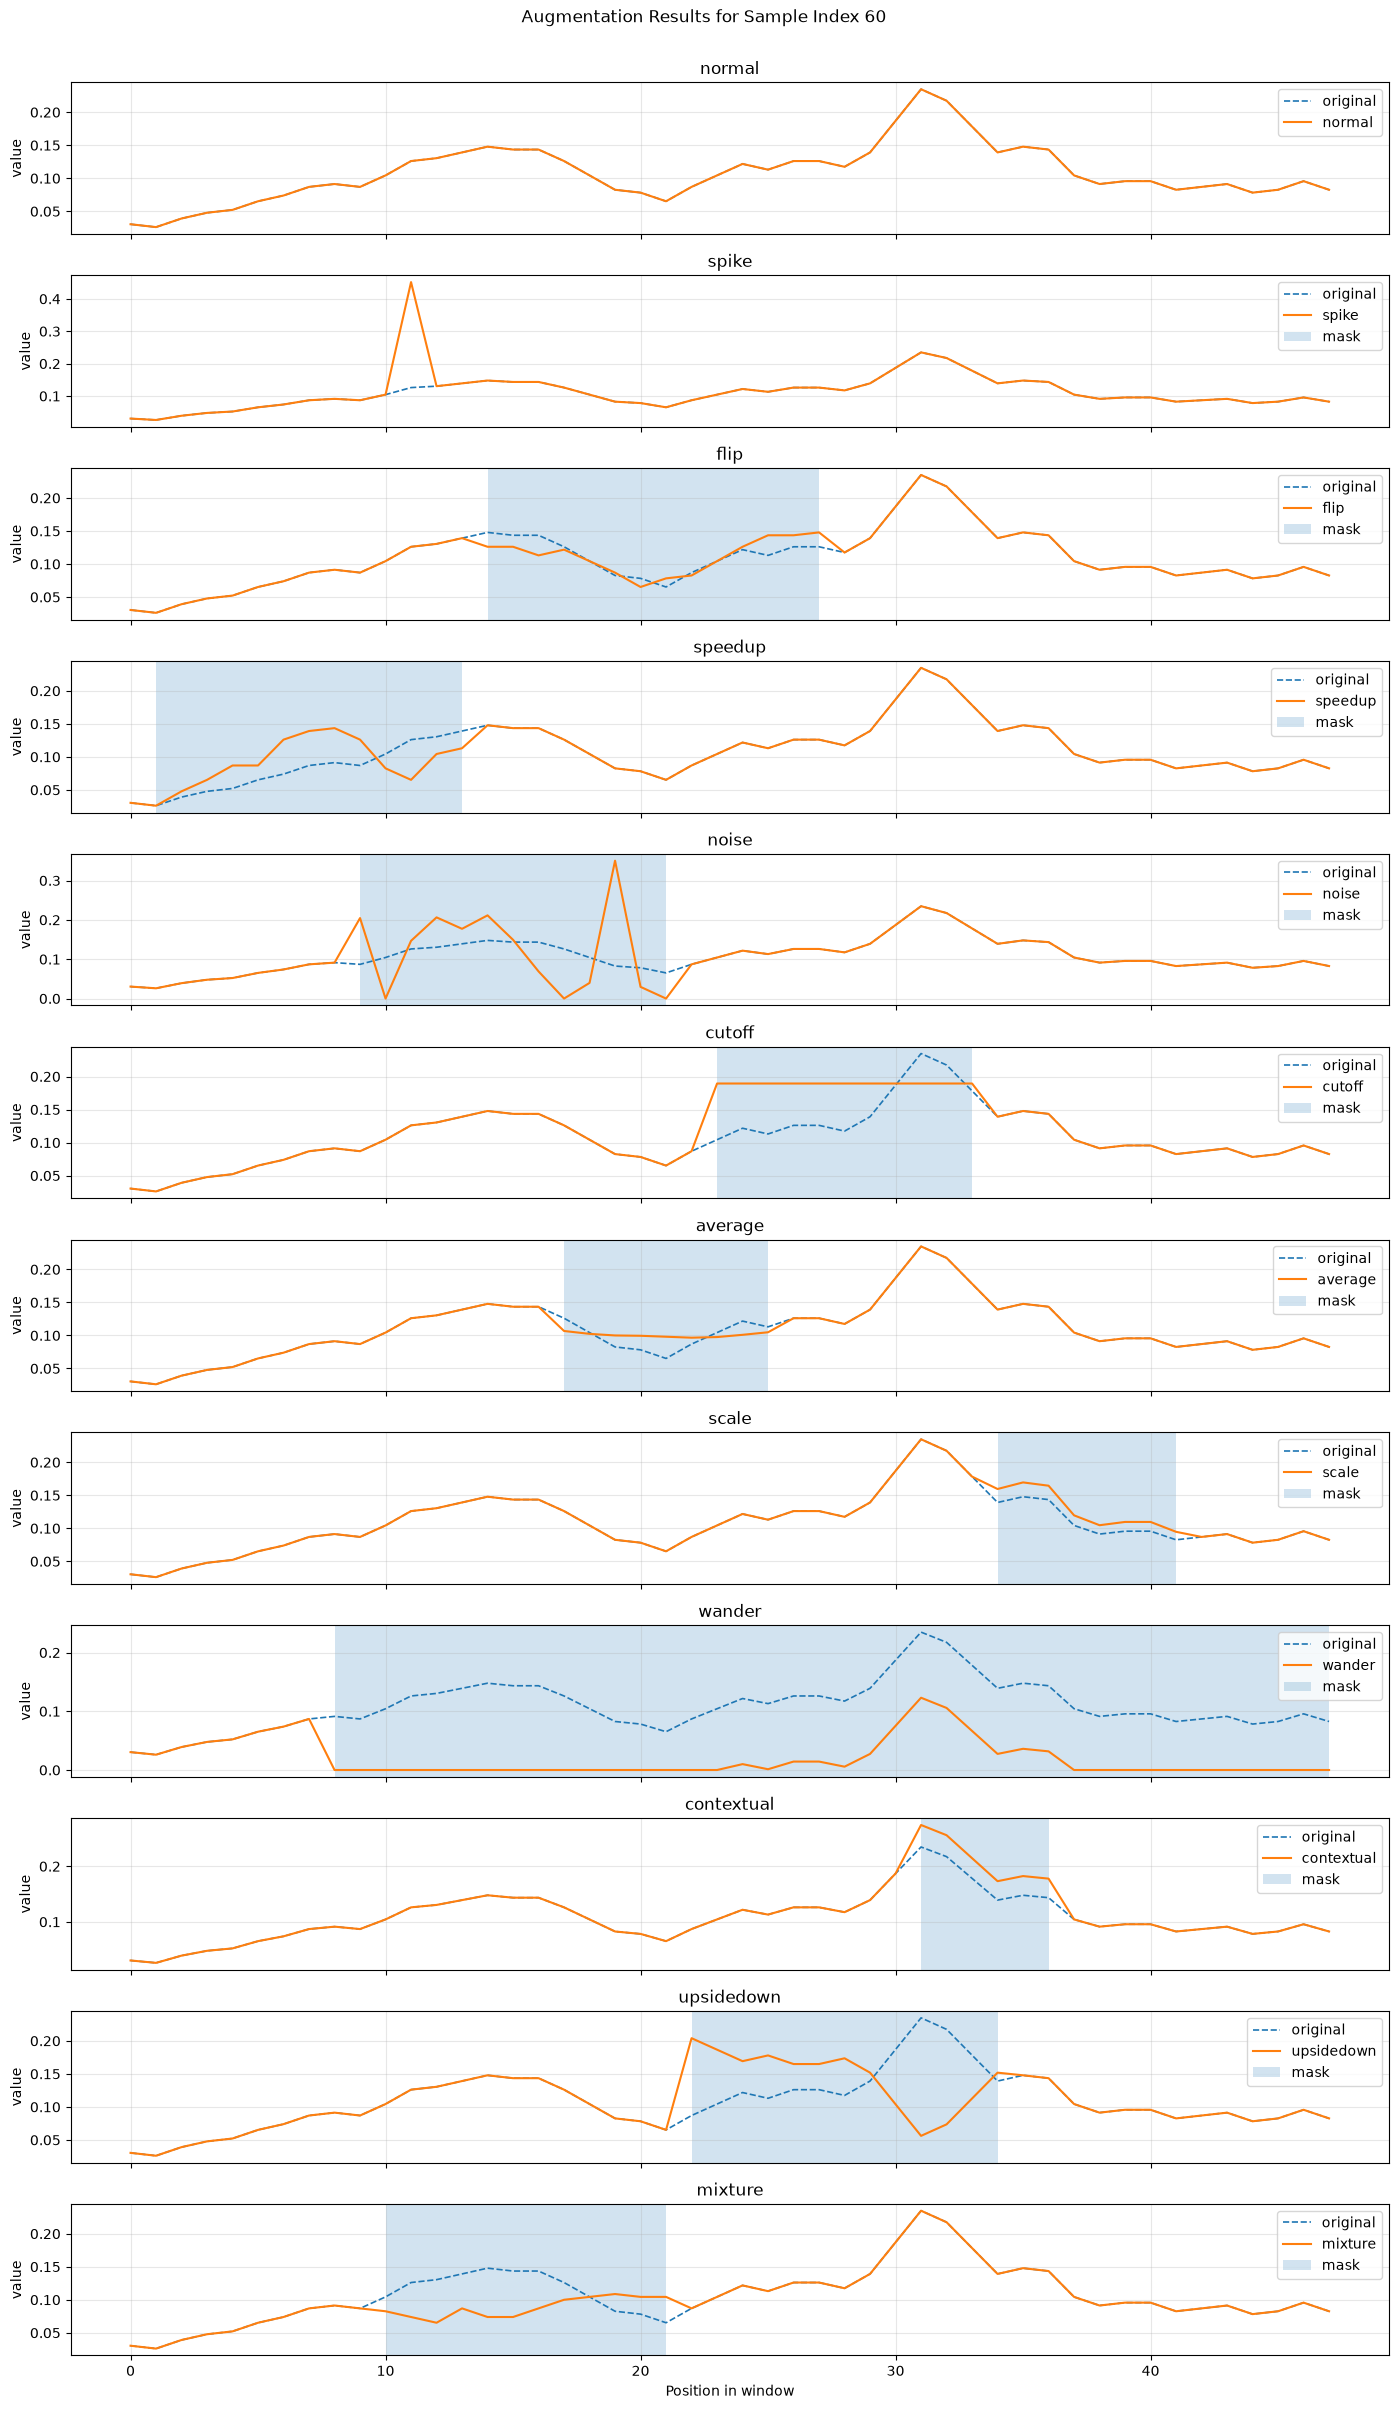

In [100]:
plot_augmented_results(
    X_aug=X_train_aug,
    Y_aug=Y_train_aug,
    W_aug=W_train_aug,
    sample_idx=60,
    class_names=selected_classes,
    show_normal=True
)

### Validation Augmentation 

In [101]:
X_val_aug, Y_val_aug, W_val_aug = augment_redlamp(
    X_val,
    selected_classes=selected_classes,
    seg_ratio_range=(0.10, 0.30),
    min_seg_len=3,
    seed=43,
    return_onehot=True
)

print("X_val      :", X_val.shape)
print("X_val_aug  :", X_val_aug.shape)
print("Y_val_aug  :", Y_val_aug.shape)
print("W_val_aug  :", W_val_aug.shape)

X_val      : (8772, 1, 48)
X_val_aug  : (105264, 1, 48)
Y_val_aug  : (105264, 12)
W_val_aug  : (105264, 1, 48)


# Label Refurbishment

In [102]:
def make_corrected_soft_labels(Y, alpha=0.1, beta=0.01, normal_idx=0):
    
    N, K = Y.shape
    Y_soft = (1.0 - alpha - K * beta) * Y + beta
    Y_soft[:, normal_idx] += alpha

    return Y_soft

In [103]:
Y_train_soft = make_corrected_soft_labels(
    Y_train_aug,
    alpha=0.1,
    beta=0.01,
    normal_idx=0
)

Y_val_soft = make_corrected_soft_labels(
    Y_val_aug,
    alpha=0.1,
    beta=0.01,
    normal_idx=0
)

In [104]:
print(Y_train_aug.shape)
print(Y_train_soft.shape)

samp = 13
print("One-hot:")
print(Y_train_aug[samp])

print("Soft-label example:")
print(Y_train_soft[samp])

print("Sum:", Y_train_soft[samp].sum())

(325476, 12)
(325476, 12)
One-hot:
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Soft-label example:
[0.11       0.78999996 0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01      ]
Sum: 0.99999994


# Data Loader

In [105]:
def make_dataloaders_from_augmented(
    X_train_aug,
    Y_train_soft,
    W_train_aug,
    X_val_aug,
    Y_val_soft,
    W_val_aug,
    batch_size=64
):
    X_train_tensor = torch.tensor(X_train_aug, dtype=torch.float32)
    W_train_tensor = torch.tensor(W_train_aug, dtype=torch.float32)

    X_val_tensor = torch.tensor(X_val_aug, dtype=torch.float32)
    W_val_tensor = torch.tensor(W_val_aug, dtype=torch.float32)

    if not torch.is_tensor(Y_train_soft):
        Y_train_tensor = torch.tensor(Y_train_soft, dtype=torch.float32)
    else:
        Y_train_tensor = Y_train_soft.float()

    if not torch.is_tensor(Y_val_soft):
        Y_val_tensor = torch.tensor(Y_val_soft, dtype=torch.float32)
    else:
        Y_val_tensor = Y_val_soft.float()

    train_dataset = TensorDataset(
        X_train_tensor,
        Y_train_tensor,
        W_train_tensor
    )

    val_dataset = TensorDataset(
        X_val_tensor,
        Y_val_tensor,
        W_val_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    return train_loader, val_loader

# Model

In [106]:
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            ),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.block(x)

In [107]:
class Encoder(nn.Module):
    def __init__(self, in_channels=1, latent_dim=32, conv_channels=[16, 32, 32, 32], dropout=0.2):
        super().__init__()

        layers = []
        prev_ch = in_channels

        for ch in conv_channels:
            layers.append(ConvBlock1D(prev_ch, ch, dropout=dropout))
            prev_ch = ch

        self.conv_blocks = nn.Sequential(*layers)

        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.final_conv = nn.Conv1d(conv_channels[-1], latent_dim, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.maxpool(x)
        z = self.final_conv(x)
        return z

In [108]:
class Decoder(nn.Module):
    def __init__(
        self,
        latent_dim=32,
        latent_len=15,
        output_len=30,
        out_channels=1,
        conv_channels=[16, 32, 32, 32],
        dropout=0.2
    ):
        super().__init__()

        self.upsample_linear = nn.Linear(latent_len, output_len)

        decoder_channels = list(reversed(conv_channels))

        layers = []
        prev_ch = latent_dim

        for ch in decoder_channels:
            layers.append(ConvBlock1D(prev_ch, ch, dropout=dropout))
            prev_ch = ch

        self.conv_blocks = nn.Sequential(*layers)

        self.final_conv = nn.Sequential(
            nn.Conv1d(prev_ch, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, z):
        z = self.upsample_linear(z)
        x_hat = self.conv_blocks(z)
        x_hat = self.final_conv(x_hat)
        return x_hat

In [109]:
class Classifier(nn.Module):
    def __init__(self, latent_dim=32, latent_len=15, num_classes=12, dropout=0.2):
        super().__init__()

        in_features = latent_dim * latent_len

        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, z):
        z = z.flatten(start_dim=1)
        logits = self.net(z)
        return logits

In [110]:
class RedLamp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        window_size=30,
        latent_dim=32,
        num_classes=12,
        conv_channels=[16, 32, 32, 32],
        dropout=0.2
    ):
        super().__init__()

        self.window_size = window_size
        self.latent_len = window_size // 2

        self.encoder = Encoder(
            in_channels=in_channels,
            latent_dim=latent_dim,
            conv_channels=conv_channels,
            dropout=dropout
        )

        self.decoder = Decoder(
            latent_dim=latent_dim,
            latent_len=self.latent_len,
            output_len=window_size,
            out_channels=in_channels,
            conv_channels=conv_channels,
            dropout=dropout
        )

        self.classifier = Classifier(
            latent_dim=latent_dim,
            latent_len=self.latent_len,
            num_classes=num_classes,
            dropout=dropout
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        logits = self.classifier(z)
        return x_hat, logits, z

In [111]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#L sudah didefinisikan pada window creation
K = len(selected_classes)

model = RedLamp(
    in_channels=1,
    window_size=L,
    latent_dim=32,
    num_classes=K,
    conv_channels=[128, 128, 256, 256],
    dropout=0.2
).to(device)

temp_train_loader, temp_val_loader = make_dataloaders_from_augmented(
    X_train_aug=X_train_aug,
    Y_train_soft=Y_train_soft,
    W_train_aug=W_train_aug,
    X_val_aug=X_val_aug,
    Y_val_soft=Y_val_soft,
    W_val_aug=W_val_aug,
    batch_size=64
)

xb, yb, wb = next(iter(temp_train_loader))
xb = xb.to(device)

with torch.no_grad():
    x_hat, logits, z = model(xb)

print("Input :", xb.shape)
print("x_hat :", x_hat.shape)
print("logits:", logits.shape)
print("z     :", z.shape)

Device: cuda
GPU: Tesla T4
Input : torch.Size([64, 1, 48])
x_hat : torch.Size([64, 1, 48])
logits: torch.Size([64, 12])
z     : torch.Size([64, 32, 24])


# LOSS FUNCTION

In [112]:
# REDLAMP LOSS
def masked_mse_loss(x, x_hat, w, eps=1e-8):

    normal_mask = 1.0 - w
    diff = (x - x_hat) * normal_mask
    loss = (diff ** 2).sum() / (normal_mask.sum() + eps)

    return loss


def soft_cross_entropy_loss(logits, y_soft):

    log_probs = F.log_softmax(logits, dim=1)
    loss = -(y_soft * log_probs).sum(dim=1).mean()

    return loss


def redlamp_loss(x, x_hat, w, logits, y_soft, gamma=0.1):

    loss_mse = masked_mse_loss(x, x_hat, w)
    loss_ce = soft_cross_entropy_loss(logits, y_soft)
    loss_total = gamma * loss_ce + (1.0 - gamma) * loss_mse

    return loss_total, loss_mse, loss_ce

# Train

In [113]:
def train_one_epoch(model, train_loader, optimizer, device, gamma=0.1):
    model.train()

    total_loss = 0.0
    total_mse = 0.0
    total_ce = 0.0

    for xb, yb, wb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        optimizer.zero_grad()

        x_hat, logits, z = model(xb)

        loss, loss_mse, loss_ce = redlamp_loss(
            x=xb,
            x_hat=x_hat,
            w=wb,
            logits=logits,
            y_soft=yb,
            gamma=gamma
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_mse += loss_mse.item()
        total_ce += loss_ce.item()

    avg_loss = total_loss / len(train_loader)
    avg_mse = total_mse / len(train_loader)
    avg_ce = total_ce / len(train_loader)

    return avg_loss, avg_mse, avg_ce

In [114]:
def validate_one_epoch(model, val_loader, device, gamma=0.1):
    model.eval()

    total_loss = 0.0
    total_mse = 0.0
    total_ce = 0.0

    with torch.no_grad():
        for xb, yb, wb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)

            x_hat, logits, z = model(xb)

            loss, loss_mse, loss_ce = redlamp_loss(
                x=xb,
                x_hat=x_hat,
                w=wb,
                logits=logits,
                y_soft=yb,
                gamma=gamma
            )

            total_loss += loss.item()
            total_mse += loss_mse.item()
            total_ce += loss_ce.item()

    avg_loss = total_loss / len(val_loader)
    avg_mse = total_mse / len(val_loader)
    avg_ce = total_ce / len(val_loader)

    return avg_loss, avg_mse, avg_ce

# Tuning

In [115]:
param_grid = {
    "batch_size": [64, 128],
    "latent_dim": [32, 64],
    "dropout": [0.2],
    "conv_channels": [
        [64, 128, 128, 128],
        [128, 128, 256, 256],
    ],
    "learning_rate": [1e-3, 5e-4],
}

fixed_params = {
    "gamma": 0.1,
    "weight_decay": 1e-5,
}

def make_tuning_configs(param_grid, fixed_params=None):
    keys = list(param_grid.keys())
    values = list(param_grid.values())

    configs = []

    for i, combination in enumerate(product(*values), start=1):
        config = dict(zip(keys, combination))

        if fixed_params is not None:
            config.update(fixed_params)

        conv_name = "x".join(map(str, config["conv_channels"]))
        lr_str = str(config["learning_rate"]).replace(".", "p").replace("-", "m")
        dropout_str = str(config["dropout"]).replace(".", "p")

        config["config_id"] = (
            f"C{i:03d}_"
            f"bs{config['batch_size']}_"
            f"lat{config['latent_dim']}_"
            f"conv{conv_name}_"
            f"lr{lr_str}_"
            f"do{dropout_str}"
        )

        configs.append(config)

    return configs


tuning_configs = make_tuning_configs(
    param_grid=param_grid,
    fixed_params=fixed_params
)

print("Total configs:", len(tuning_configs))
display(pd.DataFrame(tuning_configs))

Total configs: 16


,batch_size,latent_dim,dropout,conv_channels,learning_rate,gamma,weight_decay,config_id
0,64,32,0.2,"[64, 128, 128, 128]",0.0010,0.1,0.00001,C001_bs64_lat32_conv64x128x128x128_lr0p001_do0p2
1,64,32,0.2,"[64, 128, 128, 128]",0.0005,0.1,0.00001,C002_bs64_lat32_conv64x128x128x128_lr0p0005_do0p2
2,64,32,0.2,"[128, 128, 256, 256]",0.0010,0.1,0.00001,C003_bs64_lat32_conv128x128x256x256_lr0p001_do0p2
3,64,32,0.2,"[128, 128, 256, 256]",0.0005,0.1,0.00001,C004_bs64_lat32_conv128x128x256x256_lr0p0005_d...
4,64,64,0.2,"[64, 128, 128, 128]",0.0010,0.1,0.00001,C005_bs64_lat64_conv64x128x128x128_lr0p001_do0p2
5,64,64,0.2,"[64, 128, 128, 128]",0.0005,0.1,0.00001,C006_bs64_lat64_conv64x128x128x128_lr0p0005_do0p2
6,64,64,0.2,"[128, 128, 256, 256]",0.0010,0.1,0.00001,C007_bs64_lat64_conv128x128x256x256_lr0p001_do0p2
7,64,64,0.2,"[128, 128, 256, 256]",0.0005,0.1,0.00001,C008_bs64_lat64_conv128x128x256x256_lr0p0005_d...
8,128,32,0.2,"[64, 128, 128, 128]",0.0010,0.1,0.00001,C009_bs128_lat32_conv64x128x128x128_lr0p001_do0p2
9,128,32,0.2,"[64, 128, 128, 128]",0.0005,0.1,0.00001,C010_bs128_lat32_conv64x128x128x128_lr0p0005_d...


In [116]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [117]:
def run_one_tuning_config(
    config,
    X_train_aug,
    Y_train_soft,
    W_train_aug,
    X_val_aug,
    Y_val_soft,
    W_val_aug,
    window_size,
    num_classes,
    device,
    max_epochs=50,
    patience=7,
    min_delta=1e-5,
    seed=42,
    verbose=True
):
    set_seed(seed)

    train_loader, val_loader = make_dataloaders_from_augmented(
        X_train_aug=X_train_aug,
        Y_train_soft=Y_train_soft,
        W_train_aug=W_train_aug,
        X_val_aug=X_val_aug,
        Y_val_soft=Y_val_soft,
        W_val_aug=W_val_aug,
        batch_size=config["batch_size"]
    )

    model = RedLamp(
        in_channels=1,
        window_size=window_size,
        latent_dim=config["latent_dim"],
        num_classes=num_classes,
        conv_channels=config["conv_channels"],
        dropout=config["dropout"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    best_val_loss = float("inf")
    best_epoch = None
    best_state_dict = None
    best_metrics = None
    epochs_without_improvement = 0

    train_loss_hist = []
    train_mse_hist = []
    train_ce_hist = []

    val_loss_hist = []
    val_mse_hist = []
    val_ce_hist = []

    total_params, trainable_params = count_parameters(model)

    if verbose:
        print("=" * 80)
        print(f"Running config: {config['config_id']}")
        print("Config:", config)
        print(f"Total params    : {total_params:,}")
        print(f"Trainable params: {trainable_params:,}")
        print("=" * 80)

    for epoch in range(1, max_epochs + 1):
        train_loss, train_mse, train_ce = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            device=device,
            gamma=config["gamma"]
        )

        val_loss, val_mse, val_ce = validate_one_epoch(
            model=model,
            val_loader=val_loader,
            device=device,
            gamma=config["gamma"]
        )

        train_loss_hist.append(train_loss)
        train_mse_hist.append(train_mse)
        train_ce_hist.append(train_ce)

        val_loss_hist.append(val_loss)
        val_mse_hist.append(val_mse)
        val_ce_hist.append(val_ce)

        improved = val_loss < (best_val_loss - min_delta)

        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())

            best_metrics = {
                "train_loss": train_loss,
                "train_mse": train_mse,
                "train_ce": train_ce,
                "val_loss": val_loss,
                "val_mse": val_mse,
                "val_ce": val_ce,
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"[{config['config_id']}] "
                f"Epoch {epoch:03d}/{max_epochs} | "
                f"Train Loss: {train_loss:.5f} | "
                f"Train MSE: {train_mse:.5f} | "
                f"Train CE: {train_ce:.5f} || "
                f"Val Loss: {val_loss:.5f} | "
                f"Val MSE: {val_mse:.5f} | "
                f"Val CE: {val_ce:.5f} || "
                f"No Improve: {epochs_without_improvement}/{patience}"
            )

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    result = {
        "config_id": config["config_id"],
        "batch_size": config["batch_size"],
        "latent_dim": config["latent_dim"],
        "conv_channels": str(config["conv_channels"]),
        "learning_rate": config["learning_rate"],
        "dropout": config["dropout"],
        "gamma": config["gamma"],
        "weight_decay": config["weight_decay"],
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_train_loss": best_metrics["train_loss"],
        "best_train_mse": best_metrics["train_mse"],
        "best_train_ce": best_metrics["train_ce"],
        "best_val_mse": best_metrics["val_mse"],
        "best_val_ce": best_metrics["val_ce"],
        "total_params": total_params,
        "trainable_params": trainable_params,
        "best_state_dict": best_state_dict,
        "history": {
            "train_loss": train_loss_hist,
            "train_mse": train_mse_hist,
            "train_ce": train_ce_hist,
            "val_loss": val_loss_hist,
            "val_mse": val_mse_hist,
            "val_ce": val_ce_hist,
        },
    }

    return result

In [118]:
TUNING_MAX_EPOCHS = 15
TUNING_PATIENCE = 4

tuning_results = []

for config in tuning_configs:
    result = run_one_tuning_config(
        config=config,
        X_train_aug=X_train_aug,
        Y_train_soft=Y_train_soft,
        W_train_aug=W_train_aug,
        X_val_aug=X_val_aug,
        Y_val_soft=Y_val_soft,
        W_val_aug=W_val_aug,
        window_size=L,
        num_classes=K,
        device=device,
        max_epochs=TUNING_MAX_EPOCHS,
        patience=TUNING_PATIENCE,
        min_delta=1e-5,
        seed=42,
        verbose=True
    )

    tuning_results.append(result)

    print(
        f"{result['config_id']} | "
        f"best_epoch={result['best_epoch']} | "
        f"best_val_loss={result['best_val_loss']:.5f} | "
        f"val_mse={result['best_val_mse']:.5f} | "
        f"val_ce={result['best_val_ce']:.5f}"
    )

Running config: C001_bs64_lat32_conv64x128x128x128_lr0p001_do0p2
Config: {'batch_size': 64, 'latent_dim': 32, 'dropout': 0.2, 'conv_channels': [64, 128, 128, 128], 'learning_rate': 0.001, 'gamma': 0.1, 'weight_decay': 1e-05, 'config_id': 'C001_bs64_lat32_conv64x128x128x128_lr0p001_do0p2'}
Total params    : 324,765
Trainable params: 324,765
[C001_bs64_lat32_conv64x128x128x128_lr0p001_do0p2] Epoch 001/15 | Train Loss: 0.19890 | Train MSE: 0.00201 | Train CE: 1.97088 || Val Loss: 0.19216 | Val MSE: 0.00145 | Val CE: 1.90852 || No Improve: 0/4
[C001_bs64_lat32_conv64x128x128x128_lr0p001_do0p2] Epoch 002/15 | Train Loss: 0.18168 | Train MSE: 0.00090 | Train CE: 1.80867 || Val Loss: 0.17689 | Val MSE: 0.00049 | Val CE: 1.76447 || No Improve: 0/4
[C001_bs64_lat32_conv64x128x128x128_lr0p001_do0p2] Epoch 003/15 | Train Loss: 0.17819 | Train MSE: 0.00077 | Train CE: 1.77498 || Val Loss: 0.20337 | Val MSE: 0.00081 | Val CE: 2.02638 || No Improve: 1/4
[C001_bs64_lat32_conv64x128x128x128_lr0p001_do

In [119]:
tuning_summary = []

for r in tuning_results:
    tuning_summary.append({
        "config_id": r["config_id"],
        "batch_size": r["batch_size"],
        "latent_dim": r["latent_dim"],
        "conv_channels": r["conv_channels"],
        "learning_rate": r["learning_rate"],
        "dropout": r["dropout"],
        "gamma": r["gamma"],
        "weight_decay": r["weight_decay"],
        "best_epoch": r["best_epoch"],
        "best_val_loss": r["best_val_loss"],
        "best_train_loss": r["best_train_loss"],
        "best_val_mse": r["best_val_mse"],
        "best_val_ce": r["best_val_ce"],
        "total_params": r["total_params"],
        "trainable_params": r["trainable_params"],
    })

tuning_df = pd.DataFrame(tuning_summary)
tuning_df = tuning_df.sort_values("best_val_loss").reset_index(drop=True)

tuning_df

,config_id,batch_size,latent_dim,conv_channels,learning_rate,dropout,gamma,weight_decay,best_epoch,best_val_loss,best_train_loss,best_val_mse,best_val_ce,total_params,trainable_params
0,C008_bs64_lat64_conv128x128x256x256_lr0p0005_d...,64,64,"[128, 128, 256, 256]",0.0005,0.2,0.1,0.00001,11,0.169467,0.166798,0.000403,1.691040,892349,892349
1,C002_bs64_lat32_conv64x128x128x128_lr0p0005_do0p2,64,32,"[64, 128, 128, 128]",0.0005,0.2,0.1,0.00001,14,0.169467,0.170187,0.000572,1.689522,324765,324765
2,C001_bs64_lat32_conv64x128x128x128_lr0p001_do0p2,64,32,"[64, 128, 128, 128]",0.0010,0.2,0.1,0.00001,10,0.169597,0.170961,0.000530,1.691200,324765,324765
3,C006_bs64_lat64_conv64x128x128x128_lr0p0005_do0p2,64,64,"[64, 128, 128, 128]",0.0005,0.2,0.1,0.00001,14,0.170130,0.170175,0.000464,1.697128,398525,398525
4,C005_bs64_lat64_conv64x128x128x128_lr0p001_do0p2,64,64,"[64, 128, 128, 128]",0.0010,0.2,0.1,0.00001,15,0.170212,0.168886,0.000379,1.698717,398525,398525
5,C004_bs64_lat32_conv128x128x256x256_lr0p0005_d...,64,32,"[128, 128, 256, 256]",0.0005,0.2,0.1,0.00001,13,0.170402,0.165811,0.000594,1.698675,794013,794013
6,C011_bs128_lat32_conv128x128x256x256_lr0p001_d...,128,32,"[128, 128, 256, 256]",0.0010,0.2,0.1,0.00001,9,0.170445,0.167209,0.000389,1.700952,794013,794013
7,C016_bs128_lat64_conv128x128x256x256_lr0p0005_...,128,64,"[128, 128, 256, 256]",0.0005,0.2,0.1,0.00001,9,0.170901,0.168149,0.000288,1.706426,892349,892349
8,C007_bs64_lat64_conv128x128x256x256_lr0p001_do0p2,64,64,"[128, 128, 256, 256]",0.0010,0.2,0.1,0.00001,11,0.171727,0.165840,0.000356,1.714062,892349,892349
9,C003_bs64_lat32_conv128x128x256x256_lr0p001_do0p2,64,32,"[128, 128, 256, 256]",0.0010,0.2,0.1,0.00001,5,0.172074,0.171907,0.000469,1.716522,794013,794013


In [120]:
output_dir = Path("/kaggle/working/tune_summ")
output_dir.mkdir(parents=True, exist_ok=True)

tuning_excel_path = output_dir / "tuning_results.xlsx"

tuning_df.to_excel(
    tuning_excel_path,
    index=False
)

print("Tuning results saved to:")
print(tuning_excel_path)

Tuning results saved to:
/kaggle/working/tune_summ/tuning_results.xlsx


In [121]:
best_result = min(tuning_results, key=lambda r: r["best_val_loss"])

best_config_id = best_result["config_id"]
best_config = next(c for c in tuning_configs if c["config_id"] == best_config_id)

print("=" * 80)
print("BEST TUNING CONFIG")
print("=" * 80)
print("Best config id:", best_config_id)
print("Best config   :", best_config)
print("Best epoch    :", best_result["best_epoch"])
print("Best val loss :", best_result["best_val_loss"])
print("Best val MSE  :", best_result["best_val_mse"])
print("Best val CE   :", best_result["best_val_ce"])
print("Total params  :", f"{best_result['total_params']:,}")
print("=" * 80)

BEST TUNING CONFIG
Best config id: C008_bs64_lat64_conv128x128x256x256_lr0p0005_do0p2
Best config   : {'batch_size': 64, 'latent_dim': 64, 'dropout': 0.2, 'conv_channels': [128, 128, 256, 256], 'learning_rate': 0.0005, 'gamma': 0.1, 'weight_decay': 1e-05, 'config_id': 'C008_bs64_lat64_conv128x128x256x256_lr0p0005_do0p2'}
Best epoch    : 11
Best val loss : 0.16946680119153576
Best val MSE  : 0.0004030966626838579
Best val CE   : 1.6910401114576856
Total params  : 892,349


In [122]:
output_dir = Path("/kaggle/working/bestparams_json")
output_dir.mkdir(parents=True, exist_ok=True)

best_config_json = {
    "config_id": best_config_id,

    "batch_size": int(best_config["batch_size"]),
    "latent_dim": int(best_config["latent_dim"]),
    "conv_channels": list(best_config["conv_channels"]),
    "learning_rate": float(best_config["learning_rate"]),
    "dropout": float(best_config["dropout"]),
    "gamma": float(best_config["gamma"]),
    "weight_decay": float(best_config["weight_decay"]),

    "best_epoch": int(best_result["best_epoch"]),
    "best_val_loss": float(best_result["best_val_loss"]),
    "best_val_mse": float(best_result["best_val_mse"]),
    "best_val_ce": float(best_result["best_val_ce"]),
    "total_params": int(best_result["total_params"]),

    "seed": 42
}

best_config_path = output_dir / "best_config_baseline.json"

with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(
        best_config_json,
        f,
        indent=4
    )

print("Best config saved to:")
print(best_config_path)

Best config saved to:
/kaggle/working/bestparams_json/best_config_baseline.json


# Train and Val

In [123]:
best_model = RedLamp(
    in_channels=1,
    window_size=L,
    latent_dim=best_config["latent_dim"],
    num_classes=K,
    conv_channels=best_config["conv_channels"],
    dropout=best_config["dropout"]
).to(device)

best_model.load_state_dict(best_result["best_state_dict"])
best_model.eval()

print(best_model)

RedLamp(
  (encoder): Encoder(
    (conv_blocks): Sequential(
      (0): ConvBlock1D(
        (block): Sequential(
          (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
          (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (1): ConvBlock1D(
        (block): Sequential(
          (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
          (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (2): ConvBlock1D(
        (block): Sequential(
          (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (

In [124]:
print("Best state_dict keys:")
for k in list(best_result["best_state_dict"].keys())[:20]:
    print(k, best_result["best_state_dict"][k].shape)

print(f"... total keys: {len(best_result['best_state_dict'].keys())}")

Best state_dict keys:
encoder.conv_blocks.0.block.0.weight torch.Size([128, 1, 3])
encoder.conv_blocks.0.block.0.bias torch.Size([128])
encoder.conv_blocks.0.block.1.weight torch.Size([128])
encoder.conv_blocks.0.block.1.bias torch.Size([128])
encoder.conv_blocks.0.block.1.running_mean torch.Size([128])
encoder.conv_blocks.0.block.1.running_var torch.Size([128])
encoder.conv_blocks.0.block.1.num_batches_tracked torch.Size([])
encoder.conv_blocks.1.block.0.weight torch.Size([128, 128, 3])
encoder.conv_blocks.1.block.0.bias torch.Size([128])
encoder.conv_blocks.1.block.1.weight torch.Size([128])
encoder.conv_blocks.1.block.1.bias torch.Size([128])
encoder.conv_blocks.1.block.1.running_mean torch.Size([128])
encoder.conv_blocks.1.block.1.running_var torch.Size([128])
encoder.conv_blocks.1.block.1.num_batches_tracked torch.Size([])
encoder.conv_blocks.2.block.0.weight torch.Size([256, 128, 3])
encoder.conv_blocks.2.block.0.bias torch.Size([256])
encoder.conv_blocks.2.block.1.weight torch.S

## Train Best Model

In [125]:
def train_final_best_config(
    best_config,
    X_train_aug,
    Y_train_soft,
    W_train_aug,
    X_val_aug,
    Y_val_soft,
    W_val_aug,
    window_size,
    num_classes,
    device,
    max_epochs=100,
    patience=10,
    min_delta=1e-5,
    seed=42,
    verbose=True
):
    set_seed(seed)

    train_loader, val_loader = make_dataloaders_from_augmented(
        X_train_aug=X_train_aug,
        Y_train_soft=Y_train_soft,
        W_train_aug=W_train_aug,
        X_val_aug=X_val_aug,
        Y_val_soft=Y_val_soft,
        W_val_aug=W_val_aug,
        batch_size=best_config["batch_size"]
    )

    model = RedLamp(
        in_channels=1,
        window_size=window_size,
        latent_dim=best_config["latent_dim"],
        num_classes=num_classes,
        conv_channels=best_config["conv_channels"],
        dropout=best_config["dropout"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=best_config["learning_rate"],
        weight_decay=best_config["weight_decay"]
    )

    best_val_loss = float("inf")
    best_epoch = None
    best_state_dict = None
    best_metrics = None
    epochs_without_improvement = 0

    train_loss_hist = []
    train_mse_hist = []
    train_ce_hist = []

    val_loss_hist = []
    val_mse_hist = []
    val_ce_hist = []

    total_params, trainable_params = count_parameters(model)

    if verbose:
        print("=" * 80)
        print("FINAL TRAINING WITH BEST CONFIG")
        print("=" * 80)
        print("Best config:", best_config)
        print(f"Total params    : {total_params:,}")
        print(f"Trainable params: {trainable_params:,}")
        print("=" * 80)

    for epoch in range(1, max_epochs + 1):
        train_loss, train_mse, train_ce = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            device=device,
            gamma=best_config["gamma"]
        )

        val_loss, val_mse, val_ce = validate_one_epoch(
            model=model,
            val_loader=val_loader,
            device=device,
            gamma=best_config["gamma"]
        )

        train_loss_hist.append(train_loss)
        train_mse_hist.append(train_mse)
        train_ce_hist.append(train_ce)

        val_loss_hist.append(val_loss)
        val_mse_hist.append(val_mse)
        val_ce_hist.append(val_ce)

        improved = val_loss < (best_val_loss - min_delta)

        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())

            best_metrics = {
                "train_loss": train_loss,
                "train_mse": train_mse,
                "train_ce": train_ce,
                "val_loss": val_loss,
                "val_mse": val_mse,
                "val_ce": val_ce,
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"Epoch {epoch:03d}/{max_epochs} | "
                f"Train Loss: {train_loss:.5f} | "
                f"Train MSE: {train_mse:.5f} | "
                f"Train CE: {train_ce:.5f} || "
                f"Val Loss: {val_loss:.5f} | "
                f"Val MSE: {val_mse:.5f} | "
                f"Val CE: {val_ce:.5f} || "
                f"No Improve: {epochs_without_improvement}/{patience}"
            )

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            print(f"Best epoch: {best_epoch}")
            print(f"Best val loss: {best_val_loss:.5f}")
            break

    model.load_state_dict(best_state_dict)
    model.eval()

    final_result = {
        "model": model,
        "best_state_dict": best_state_dict,
        "best_config": best_config,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_metrics": best_metrics,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "history": {
            "train_loss": train_loss_hist,
            "train_mse": train_mse_hist,
            "train_ce": train_ce_hist,
            "val_loss": val_loss_hist,
            "val_mse": val_mse_hist,
            "val_ce": val_ce_hist,
        }
    }

    return final_result

In [126]:
FINAL_MAX_EPOCHS = 100
FINAL_PATIENCE = 10

final_result = train_final_best_config(
    best_config=best_config,
    X_train_aug=X_train_aug,
    Y_train_soft=Y_train_soft,
    W_train_aug=W_train_aug,
    X_val_aug=X_val_aug,
    Y_val_soft=Y_val_soft,
    W_val_aug=W_val_aug,
    window_size=L,
    num_classes=K,
    device=device,
    max_epochs=FINAL_MAX_EPOCHS,
    patience=FINAL_PATIENCE,
    min_delta=1e-5,
    seed=42,
    verbose=True
)

FINAL TRAINING WITH BEST CONFIG
Best config: {'batch_size': 64, 'latent_dim': 64, 'dropout': 0.2, 'conv_channels': [128, 128, 256, 256], 'learning_rate': 0.0005, 'gamma': 0.1, 'weight_decay': 1e-05, 'config_id': 'C008_bs64_lat64_conv128x128x256x256_lr0p0005_do0p2'}
Total params    : 892,349
Trainable params: 892,349
Epoch 001/100 | Train Loss: 0.20254 | Train MSE: 0.00307 | Train CE: 1.99778 || Val Loss: 0.18155 | Val MSE: 0.00077 | Val CE: 1.80858 || No Improve: 0/10
Epoch 002/100 | Train Loss: 0.18115 | Train MSE: 0.00076 | Train CE: 1.80465 || Val Loss: 0.17883 | Val MSE: 0.00042 | Val CE: 1.78445 || No Improve: 0/10
Epoch 003/100 | Train Loss: 0.17701 | Train MSE: 0.00061 | Train CE: 1.76462 || Val Loss: 0.18845 | Val MSE: 0.00063 | Val CE: 1.87882 || No Improve: 1/10
Epoch 004/100 | Train Loss: 0.17472 | Train MSE: 0.00054 | Train CE: 1.74234 || Val Loss: 0.17269 | Val MSE: 0.00032 | Val CE: 1.72398 || No Improve: 0/10
Epoch 005/100 | Train Loss: 0.17302 | Train MSE: 0.00052 | Tra

In [127]:
final_model = final_result["model"]

print("=" * 80)
print("FINAL BEST MODEL SUMMARY")
print("=" * 80)
print("Best config:")
print(final_result["best_config"])
print()
print("Best epoch:", final_result["best_epoch"])
print("Best val loss:", final_result["best_val_loss"])
print("Best metrics:")
print(final_result["best_metrics"])
print("Total params:", f"{final_result['total_params']:,}")
print("Trainable params:", f"{final_result['trainable_params']:,}")
print("=" * 80)

print(final_model)

FINAL BEST MODEL SUMMARY
Best config:
{'batch_size': 64, 'latent_dim': 64, 'dropout': 0.2, 'conv_channels': [128, 128, 256, 256], 'learning_rate': 0.0005, 'gamma': 0.1, 'weight_decay': 1e-05, 'config_id': 'C008_bs64_lat64_conv128x128x256x256_lr0p0005_do0p2'}

Best epoch: 16
Best val loss: 0.16932648967464645
Best metrics:
{'train_loss': 0.1642522488054543, 'train_mse': 0.00041625825120414936, 'train_ce': 1.6387761338367455, 'val_loss': 0.16932648967464645, 'val_mse': 0.0005424095218390171, 'val_ce': 1.6883831819864754}
Total params: 892,349
Trainable params: 892,349
RedLamp(
  (encoder): Encoder(
    (conv_blocks): Sequential(
      (0): ConvBlock1D(
        (block): Sequential(
          (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
          (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (1): ConvBlock1D(
        (block): Sequential(
   

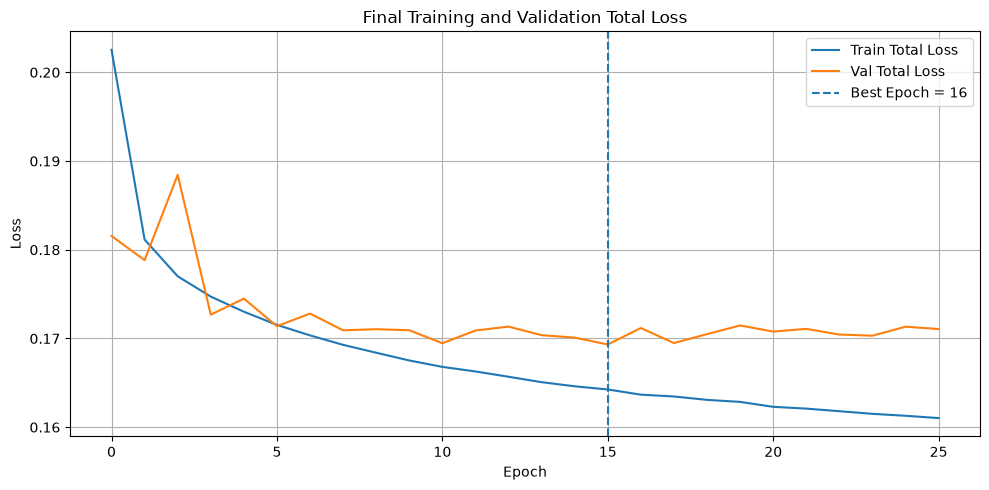

In [128]:
final_hist = final_result["history"]

plt.figure(figsize=(10, 5))
plt.plot(final_hist["train_loss"], label="Train Total Loss")
plt.plot(final_hist["val_loss"], label="Val Total Loss")
plt.axvline(final_result["best_epoch"] - 1, linestyle="--", label=f"Best Epoch = {final_result['best_epoch']}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Training and Validation Total Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

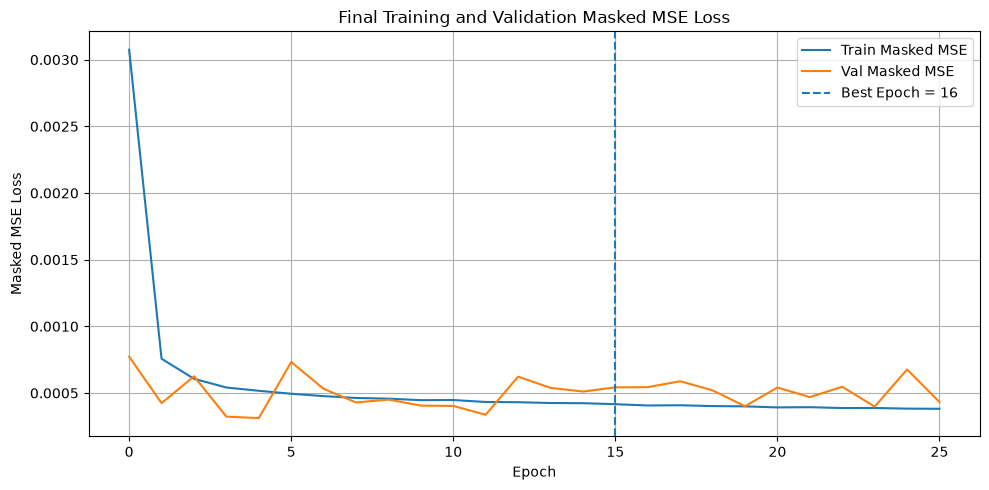

In [129]:
plt.figure(figsize=(10, 5))
plt.plot(final_hist["train_mse"], label="Train Masked MSE")
plt.plot(final_hist["val_mse"], label="Val Masked MSE")
plt.axvline(final_result["best_epoch"] - 1, linestyle="--", label=f"Best Epoch = {final_result['best_epoch']}")
plt.xlabel("Epoch")
plt.ylabel("Masked MSE Loss")
plt.title("Final Training and Validation Masked MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

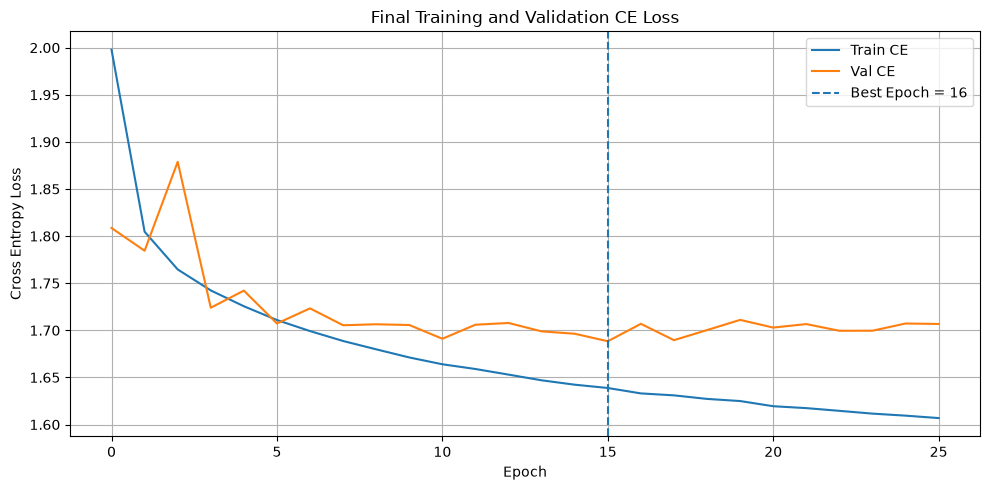

In [130]:
plt.figure(figsize=(10, 5))
plt.plot(final_hist["train_ce"], label="Train CE")
plt.plot(final_hist["val_ce"], label="Val CE")
plt.axvline(final_result["best_epoch"] - 1, linestyle="--", label=f"Best Epoch = {final_result['best_epoch']}")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Final Training and Validation CE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Test

In [131]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

test_loader = DataLoader(
    X_test_tensor,
    batch_size=best_config["batch_size"],
    shuffle=False,
    drop_last=False
)

print("X_test_tensor:", X_test_tensor.shape)

X_test_tensor: torch.Size([9210, 1, 48])


In [132]:
def inference_redlamp(model, test_loader, device):
    model.eval()

    all_x = []
    all_x_hat = []
    all_logits = []

    with torch.no_grad():
        for xb in test_loader:
            xb = xb.to(device)

            x_hat, logits, z = model(xb)

            all_x.append(xb.cpu())
            all_x_hat.append(x_hat.cpu())
            all_logits.append(logits.cpu())

    X_all = torch.cat(all_x, dim=0)
    X_hat_all = torch.cat(all_x_hat, dim=0)
    logits_all = torch.cat(all_logits, dim=0)

    return X_all, X_hat_all, logits_all

In [133]:
X_test_model, X_test_hat, test_logits = inference_redlamp(
    model=final_model,
    test_loader=test_loader,
    device=device
)

print("X_test_model:", X_test_model.shape)
print("X_test_hat  :", X_test_hat.shape)
print("test_logits :", test_logits.shape)

X_test_model: torch.Size([9210, 1, 48])
X_test_hat  : torch.Size([9210, 1, 48])
test_logits : torch.Size([9210, 12])


# Scoring

In [134]:
# 1. mse / reconstruction error per window
s_mse = ((X_test_model - X_test_hat) ** 2).sum(dim=(1, 2)).numpy()

print("s_mse shape:", s_mse.shape)
print("s_mse min/max:", s_mse.min(), s_mse.max())

s_mse shape: (9210,)
s_mse min/max: 0.00061394164 1.0952891


In [135]:
# 2. Classification anomaly score + FAA
def apply_faa(probs,delta=0.0833,normal_idx=0, skip_binary=True
):
    """
    K = 2:
        FAA dilewati karena hanya ada satu pseudo-anomaly class.
        s_ce = probabilitas pseudo-anomaly tersebut.

    K > 2:
        Pseudo-anomaly class dengan mean probability > delta
        dianggap frequent dan kontribusinya dihapus.
    """
    probs = np.asarray(probs, dtype=float)

    if probs.ndim != 2:
        raise ValueError(
            "probs harus berbentuk (n_windows, n_classes)."
        )

    n_samples, n_classes = probs.shape

    if n_samples == 0:
        raise ValueError("probs tidak boleh kosong.")

    if not (0 <= normal_idx < n_classes):
        raise ValueError("normal_idx berada di luar jumlah kelas.")

    if not np.isfinite(probs).all():
        raise ValueError("probs mengandung NaN atau inf.")

    # Cek bahwa probabilitas softmax berjumlah sekitar 1
    if not np.allclose(
        probs.sum(axis=1),
        1.0,
        atol=1e-5
    ):
        raise ValueError(
            "Jumlah probabilitas tiap window tidak sama dengan 1."
        )

    anomaly_indices = [
        i for i in range(n_classes)
        if i != normal_idx
    ]

    if len(anomaly_indices) == 0:
        raise ValueError(
            "Model tidak memiliki pseudo-anomaly class."
        )

    class_mean_probs = probs.mean(axis=0)
    probs_faa = probs.copy()

    # One Class: normal + satu pseudo-anomaly
    if skip_binary and n_classes == 2:
        pseudo_idx = anomaly_indices[0]

        removed_classes = []
        retained_classes = [pseudo_idx]

        # FAA dilewati
        s_ce = probs[:, pseudo_idx].copy()

        faa_applied = False
        scoring_mode = "binary_no_faa"

    # Multiclass: FAA diterapkan
    else:
        removed_classes = []

        for class_idx in anomaly_indices:
            # Frequent pseudo-anomaly dianggap pseudo-normal
            if class_mean_probs[class_idx] > delta:
                probs_faa[:, class_idx] = 0.0
                removed_classes.append(class_idx)

        retained_classes = [
            i for i in anomaly_indices
            if i not in removed_classes
        ]

        # Jumlah probabilitas pseudo-anomaly yang tersisa
        if retained_classes:
            s_ce = probs_faa[:, retained_classes].sum(axis=1)
        else:
            s_ce = np.zeros(
                n_samples,
                dtype=float
            )

        faa_applied = True
        scoring_mode = "multiclass_faa"

    return {
        "s_ce": s_ce,
        "probs_faa": probs_faa,
        "class_mean_probs": class_mean_probs,
        "removed_classes": removed_classes,
        "retained_classes": retained_classes,
        "faa_applied": faa_applied,
        "scoring_mode": scoring_mode
    }

In [136]:
test_probs = (
    torch.softmax(test_logits, dim=1)
    .detach()
    .cpu()
    .numpy()
)

faa_result = apply_faa(
    probs=test_probs,
    delta= 0.0833, #Delta mengikuti 1/k
    normal_idx=0,
    skip_binary=True
)

s_ce = faa_result["s_ce"]
probs_faa = faa_result["probs_faa"]
class_mean_probs = faa_result["class_mean_probs"]
removed_classes = faa_result["removed_classes"]
retained_classes = faa_result["retained_classes"]
faa_applied = faa_result["faa_applied"]
scoring_mode = faa_result["scoring_mode"]

print("FAA applied:", faa_applied)
print("s_ce shape:", s_ce.shape)
print("Removed classes:", removed_classes)

print("\nMean probability per class:")
for i, p in enumerate(class_mean_probs):
    print(f"{i:02d} {selected_classes[i]:12s}: {p:.4f}")

FAA applied: True
s_ce shape: (9210,)
Removed classes: [2, 7, 9]

Mean probability per class:
00 normal      : 0.2593
01 spike       : 0.0432
02 flip        : 0.0947
03 speedup     : 0.0763
04 noise       : 0.0422
05 cutoff      : 0.0090
06 average     : 0.0454
07 scale       : 0.1343
08 wander      : 0.0697
09 contextual  : 0.0909
10 upsidedown  : 0.0817
11 mixture     : 0.0533


In [137]:
# 3. S total/ Total Anomaly Score
def minmax_norm(x, eps=1e-8):
    x = np.asarray(x)
    return (x - x.min()) / (x.max() - x.min() + eps)

s_mse_norm = minmax_norm(s_mse)
s_ce_norm = minmax_norm(s_ce)

score_variants = {
    "reconstruction_only": s_mse_norm,
    "classification_only": s_ce_norm,
    "combined": (
        0.5 * s_mse_norm
        + 0.5 * s_ce_norm
    )
}

# Supaya kode lama tetap bisa dipakai
final_score = score_variants["combined"]

for score_name, score_values in score_variants.items():
    print(
        f"{score_name:22s} "
        f"shape={score_values.shape}, "
        f"min={score_values.min():.6f}, "
        f"max={score_values.max():.6f}, "
        f"std={score_values.std():.6f}"
    )

reconstruction_only    shape=(9210,), min=0.000000, max=1.000000, std=0.113487
classification_only    shape=(9210,), min=0.000000, max=1.000000, std=0.233948
combined               shape=(9210,), min=0.001797, max=0.919699, std=0.145346


In [138]:
test_score_df = pd.DataFrame({
    "test_window_idx": np.arange(len(final_score)),
    "window_idx": test_window_info["window_idx"].values,
    "window_start_datetime": (test_window_info["window_start_datetime"].values),
    "window_end_datetime": (test_window_info["window_end_datetime"].values),
    "s_mse": s_mse,
    "reconstruction_score": s_mse_norm,
    "s_ce_faa": s_ce,
    "classification_score": s_ce_norm,
    "combined_score": final_score,
    "label_window": y_test_window,
    "n_anomaly_points": (test_window_info["n_anomaly_points"].values)
})

test_score_df.head()

,test_window_idx,window_idx,window_start_datetime,window_end_datetime,s_mse,reconstruction_score,s_ce_faa,classification_score,combined_score,label_window,n_anomaly_points
0,0,0,2023-06-01 00:00:00,2023-06-01 23:30:00,0.013532,0.011801,0.552540,0.513419,0.262610,0,0
1,1,1,2023-06-01 00:30:00,2023-06-02 00:00:00,0.014736,0.012900,0.537592,0.495179,0.254040,0,0
2,2,2,2023-06-01 01:00:00,2023-06-02 00:30:00,0.010233,0.008787,0.550098,0.510440,0.259613,0,0
3,3,3,2023-06-01 01:30:00,2023-06-02 01:00:00,0.014779,0.012940,0.530819,0.486914,0.249927,0,0
4,4,4,2023-06-01 02:00:00,2023-06-02 01:30:00,0.025358,0.022604,0.524741,0.479499,0.251052,0,0


In [139]:
def map_window_score_to_endpoint(
    window_scores,
    window_info,
    n_points,
    window_size,
    fill_value=np.nan
):
    """
    REDLAMP-style endpoint mapping:
    skor window diberikan ke titik akhir window.
    """
    point_scores = np.full(n_points, fill_value, dtype=float)

    for score, (_, row) in zip(window_scores, window_info.iterrows()):
        start = int(row["window_idx"])
        end_idx = start + window_size - 1

        if 0 <= end_idx < n_points:
            point_scores[end_idx] = score

    return point_scores


test_df_eval = test_df.copy().reset_index(drop=True)

endpoint_score_cols = {}

for score_name, window_scores in score_variants.items():
    score_col = f"score_endpoint_{score_name}"

    test_df_eval[score_col] = map_window_score_to_endpoint(
        window_scores=window_scores,
        window_info=test_window_info,
        n_points=len(test_df_eval),
        window_size=L,
        fill_value=np.nan
    )

    endpoint_score_cols[score_name] = score_col


print("Total test points:", len(test_df_eval))

for score_name, score_col in endpoint_score_cols.items():
    print(
        f"{score_name:22s} "
        f"valid={test_df_eval[score_col].notna().sum()}, "
        f"NaN={test_df_eval[score_col].isna().sum()}"
    )

display(
    test_df_eval[
        [
            "datetime",
            "pm25_clean",
            "pm25_model",
            "label_eval_clean",
            "score_endpoint_reconstruction_only",
            "score_endpoint_classification_only",
            "score_endpoint_combined"
        ]
    ].head(L + 5)
)

Total test points: 10272
reconstruction_only    valid=9210, NaN=1062
classification_only    valid=9210, NaN=1062
combined               valid=9210, NaN=1062


,datetime,pm25_clean,pm25_model,label_eval_clean,score_endpoint_reconstruction_only,score_endpoint_classification_only,score_endpoint_combined
0,2023-06-01 00:00:00,88.0,88.0,0.0,NaN,NaN,NaN
1,2023-06-01 00:30:00,93.0,93.0,0.0,NaN,NaN,NaN
2,2023-06-01 01:00:00,88.0,88.0,0.0,NaN,NaN,NaN
3,2023-06-01 01:30:00,80.0,80.0,0.0,NaN,NaN,NaN
4,2023-06-01 02:00:00,63.0,63.0,0.0,NaN,NaN,NaN
5,2023-06-01 02:30:00,44.0,44.0,0.0,NaN,NaN,NaN
6,2023-06-01 03:00:00,35.0,35.0,0.0,NaN,NaN,NaN
7,2023-06-01 03:30:00,31.0,31.0,0.0,NaN,NaN,NaN
8,2023-06-01 04:00:00,35.0,35.0,0.0,NaN,NaN,NaN
9,2023-06-01 04:30:00,38.0,38.0,0.0,NaN,NaN,NaN


In [140]:
def labels_to_ranges(labels):
    labels = np.asarray(labels).astype(int)

    padded = np.pad(labels, (1, 1), constant_values=0)
    changes = np.diff(padded)

    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0] - 1

    return list(zip(starts, ends))

In [141]:
label_col = "label_eval_clean"

point_eval_mask = test_df_eval[label_col].notna()

for score_col in endpoint_score_cols.values():
    point_eval_mask &= test_df_eval[score_col].notna()

test_df_eval["is_eval_point"] = (
    point_eval_mask.astype(int)
)

if point_eval_mask.sum() == 0:
    raise ValueError(
        "Tidak ada titik dengan label dan seluruh score valid."
    )

# Contiguous valid segments
valid_positions = np.flatnonzero(
    point_eval_mask.to_numpy()
)

segment_ids = np.cumsum(
    np.r_[
        1,
        (np.diff(valid_positions) != 1).astype(int)
    ]
)

test_df_eval["eval_segment_id"] = pd.Series(
    pd.NA,
    index=test_df_eval.index,
    dtype="Int64"
)

test_df_eval.loc[
    valid_positions,
    "eval_segment_id"
] = segment_ids

# Ground truth yang sama untuk semua score
y_point = (
    test_df_eval.loc[
        point_eval_mask,
        label_col
    ]
    .astype(int)
    .to_numpy()
)

evaluation_coverage = float(
    point_eval_mask.mean()
)

n_eval_segments = int(
    test_df_eval["eval_segment_id"]
    .nunique(dropna=True)
)

print("Full test timeline       :", len(test_df_eval))
print("Evaluated points         :", len(y_point))
print("Evaluated anomaly points :", int(y_point.sum()))
print("Evaluation coverage      :", evaluation_coverage)
print("Evaluation segments      :", n_eval_segments)

Full test timeline       : 10272
Evaluated points         : 9210
Evaluated anomaly points : 361
Evaluation coverage      : 0.8966121495327103
Evaluation segments      : 16


## Metrics

In [142]:
def safe_roc_auc(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score).astype(float)

    if len(y_true) == 0:
        return np.nan

    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(
        roc_auc_score(y_true, score)
    )


def safe_point_pr_auc(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score).astype(float)

    if len(y_true) == 0:
        return np.nan

    if len(np.unique(y_true)) < 2:
        return np.nan

    precision, recall, _ = precision_recall_curve(
        y_true,
        score
    )

    return float(
        auc(recall, precision)
    )


point_metric_rows = []

for score_name, score_col in endpoint_score_cols.items():
    score_point_variant = (
        test_df_eval.loc[
            point_eval_mask,
            score_col
        ]
        .astype(float)
        .to_numpy()
    )

    point_metric_rows.append({
        "score_variant": score_name,
        "point_roc_auc": safe_roc_auc(
            y_point,
            score_point_variant
        ),
        "point_pr_auc": safe_point_pr_auc(
            y_point,
            score_point_variant
        )
    })

point_metrics_df = pd.DataFrame(
    point_metric_rows
)

display(point_metrics_df)

,score_variant,point_roc_auc,point_pr_auc
0,reconstruction_only,0.912909,0.253834
1,classification_only,0.697791,0.067775
2,combined,0.785798,0.161966


In [143]:
label_for_vus_window = (
    test_df_eval["label_eval_clean"]
    .fillna(0)
    .astype(int)
    .to_numpy()
)

gt_ranges_vus = labels_to_ranges(label_for_vus_window)

if len(gt_ranges_vus) == 0:
    raise ValueError("Tidak ada ground-truth anomaly event pada test set.")

event_lengths_vus = np.array([
    end - start + 1
    for start, end in gt_ranges_vus
])

VUS_MAX_BUFFER = max(
    1,
    int(np.median(event_lengths_vus))
)

print("VUS maximum buffer:", VUS_MAX_BUFFER)
print("Duration:", VUS_MAX_BUFFER * 0.5, "hours")
print("GT anomaly events :", len(gt_ranges_vus))
print("Median event length:", np.median(event_lengths_vus))

VUS maximum buffer: 7
Duration: 3.5 hours
GT anomaly events : 47
Median event length: 7.0


In [144]:
def build_guarded_vus_input(
    df_eval,
    label_col="label_eval_clean",
    score_col="score_endpoint",
    segment_col="eval_segment_id",
    vus_max_buffer=1
):
    """
    Menyatukan contiguous valid segments untuk VUS.

    Antarsegmen diberi guard region normal lebih panjang daripada
    maximum VUS buffer, sehingga buffer tidak melintasi gap invalid.
    """
    valid_df = df_eval[
        df_eval[label_col].notna() &
        df_eval[score_col].notna() &
        df_eval[segment_col].notna()
    ].copy()

    if valid_df.empty:
        raise ValueError("Tidak ada titik valid untuk evaluasi VUS.")

    valid_df[segment_col] = valid_df[segment_col].astype(int)

    segment_ids = (
        valid_df[segment_col]
        .drop_duplicates()
        .tolist()
    )

    valid_scores = valid_df[score_col].to_numpy(dtype=float)

    if not np.isfinite(valid_scores).all():
        raise ValueError("Valid endpoint score mengandung NaN atau inf.")

    guard_length = int(vus_max_buffer) + 1

    # Skor guard dibuat sedikit lebih rendah daripada skor valid terendah
    guard_score = np.nextafter(
        valid_scores.min(),
        -np.inf
    )

    label_parts = []
    score_parts = []

    for i, segment_id in enumerate(segment_ids):
        segment = valid_df[
            valid_df[segment_col] == segment_id
        ]

        segment_labels = (
            segment[label_col]
            .astype(int)
            .to_numpy()
        )

        segment_scores = (
            segment[score_col]
            .astype(float)
            .to_numpy()
        )

        label_parts.append(segment_labels)
        score_parts.append(segment_scores)

        # Tambahkan guard hanya di antara dua segmen
        if i < len(segment_ids) - 1:
            label_parts.append(
                np.zeros(guard_length, dtype=int)
            )

            score_parts.append(
                np.full(
                    guard_length,
                    guard_score,
                    dtype=float
                )
            )

    label_vus = np.concatenate(label_parts)
    score_vus = np.concatenate(score_parts)

    info = {
        "n_valid_points": len(valid_df),
        "n_segments": len(segment_ids),
        "guard_length": guard_length,
        "n_guard_points": (
            max(0, len(segment_ids) - 1)
            * guard_length
        ),
        "n_vus_input_points": len(label_vus)
    }

    return label_vus, score_vus, info

In [145]:
ablation_rows = []

for score_name, score_col in endpoint_score_cols.items():

    score_point_variant = (
        test_df_eval.loc[
            point_eval_mask,
            score_col
        ]
        .astype(float)
        .to_numpy()
    )

    point_roc_auc_variant = safe_roc_auc(
        y_point,
        score_point_variant
    )

    point_pr_auc_variant = safe_point_pr_auc(
        y_point,
        score_point_variant
    )

    label_vus, score_vus, vus_input_info = build_guarded_vus_input(
        df_eval=test_df_eval,
        label_col="label_eval_clean",
        score_col=score_col,
        segment_col="eval_segment_id",
        vus_max_buffer=VUS_MAX_BUFFER
    )

    if label_vus.shape != score_vus.shape:
        raise ValueError(
            f"{score_name}: VUS shape mismatch."
        )

    if len(np.unique(label_vus)) < 2:
        raise ValueError(
            f"{score_name}: input VUS hanya satu kelas."
        )

    vus_metrics_variant = get_metrics(
        score_vus,
        label_vus,
        metric="vus",
        slidingWindow=VUS_MAX_BUFFER
    )

    ablation_rows.append({
        "score_variant": score_name,
        "vus_roc": float(vus_metrics_variant["VUS_ROC"]),
        "vus_pr": float(vus_metrics_variant["VUS_PR"]),
        "point_roc_auc": float(point_roc_auc_variant),
        "point_pr_auc": float(point_pr_auc_variant),
        "n_point_eval": int(point_eval_mask.sum()),
        "n_point_anomaly": int(y_point.sum()),
        "evaluation_coverage": float(point_eval_mask.mean()),
        "n_eval_segments": int(vus_input_info["n_segments"]),
        "n_guard_points": int(vus_input_info["n_guard_points"]),
        "vus_max_buffer": int(VUS_MAX_BUFFER)
    })

score_ablation_df = pd.DataFrame(ablation_rows)

score_ablation_df = score_ablation_df[
    [
        "score_variant",
        "vus_roc",
        "vus_pr",
        "point_roc_auc",
        "point_pr_auc",
        "n_point_eval",
        "n_point_anomaly",
        "evaluation_coverage",
        "n_eval_segments",
        "n_guard_points",
        "vus_max_buffer"
    ]
]

display(score_ablation_df)

,score_variant,vus_roc,vus_pr,point_roc_auc,point_pr_auc,n_point_eval,n_point_anomaly,evaluation_coverage,n_eval_segments,n_guard_points,vus_max_buffer
0,reconstruction_only,0.906150,0.279786,0.912909,0.253834,9210,361,0.896612,16,120,7
1,classification_only,0.685864,0.089628,0.697791,0.067775,9210,361,0.896612,16,120,7
2,combined,0.764314,0.151991,0.785798,0.161966,9210,361,0.896612,16,120,7


In [146]:
combined_result = (
    score_ablation_df[
        score_ablation_df["score_variant"] == "combined"
    ]
    .iloc[0]
)

metrics_result = {
    "vus_roc": float(combined_result["vus_roc"]),
    "vus_pr": float(combined_result["vus_pr"]),
    "point_roc_auc": float(
        combined_result["point_roc_auc"]
    ),
    "point_pr_auc": float(
        combined_result["point_pr_auc"]
    ),

    "vus_max_buffer": int(VUS_MAX_BUFFER),

    "n_test_points": int(len(test_df_eval)),
    "n_point_eval": int(
        combined_result["n_point_eval"]
    ),
    "n_point_anomaly": int(
        combined_result["n_point_anomaly"]
    ),
    "evaluation_coverage": float(
        combined_result["evaluation_coverage"]
    ),

    "n_eval_segments": int(
        combined_result["n_eval_segments"]
    ),
    "n_guard_points": int(
        combined_result["n_guard_points"]
    )
}

metrics_df = pd.DataFrame([metrics_result])

display(metrics_df)

,vus_roc,vus_pr,point_roc_auc,point_pr_auc,vus_max_buffer,n_test_points,n_point_eval,n_point_anomaly,evaluation_coverage,n_eval_segments,n_guard_points
0,0.764314,0.151991,0.785798,0.161966,7,10272,9210,361,0.896612,16,120


In [147]:
point_prediction_df = test_df_eval[
    [
        "datetime",
        "pm25_clean",
        "pm25_model",
        "label_eval_clean",
        "score_endpoint_reconstruction_only",
        "score_endpoint_classification_only",
        "score_endpoint_combined",
        "is_eval_point",
        "eval_segment_id"
    ]
].copy()

In [148]:
output_dir = Path("/kaggle/working/results")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

scenario_id = f"L{L}_K{K}"
result_path = output_dir / f"result_L{L}_K{K}.xlsx"

durasi_window = f"{L * 0.5:g} jam"

pseudo_classes_text = (
    "full REDLAMP"
    if K == 12
    else ",".join(selected_classes[1:])
)

scenario_record = {
    "scenario_id": scenario_id,
    "L": int(L),
    "durasi_window": durasi_window,
    "K": int(K),
    "pseudo_classes": pseudo_classes_text,
    "stride": 1,

    "train_windows": int(len(X_train)),
    "val_windows": int(len(X_val)),
    "test_windows": int(len(X_test)),

    "test_timeline_points": int(
        metrics_df.loc[0, "n_test_points"]
    ),

    "point_eval": int(
        metrics_df.loc[0, "n_point_eval"]
    ),

    "point_anomaly": int(
        metrics_df.loc[0, "n_point_anomaly"]
    ),

    "evaluation_coverage": float(
        metrics_df.loc[0, "evaluation_coverage"]
    ),

    "n_eval_segments": int(
        metrics_df.loc[0, "n_eval_segments"]
    ),

    "vus_max_buffer": int(
        metrics_df.loc[0, "vus_max_buffer"]
    ),

    # Combined score sebagai hasil utama
    "vus_roc": float(
        metrics_df.loc[0, "vus_roc"]
    ),

    "vus_pr": float(
        metrics_df.loc[0, "vus_pr"]
    ),

    "point_roc_auc": float(
        metrics_df.loc[0, "point_roc_auc"]
    ),

    "point_pr_auc": float(
        metrics_df.loc[0, "point_pr_auc"]
    ),

    "best_epoch": int(
        final_result["best_epoch"]
    ),

    "best_val_loss": float(
        final_result["best_val_loss"]
    ),

    "catatan": (
        "Combined score digunakan sebagai hasil utama. "
        "Reconstruction-only dan classification-only "
        "tersedia pada sheet score_ablation."
    )
}

scenario_summary_df = pd.DataFrame(
    [scenario_record]
)

with pd.ExcelWriter(
    result_path,
    engine="openpyxl"
) as writer:

    scenario_summary_df.to_excel(
        writer,
        sheet_name="scenario_result",
        index=False
    )

    score_ablation_df.to_excel(
        writer,
        sheet_name="score_ablation",
        index=False
    )
    
    point_prediction_df.to_excel(
        writer,
        sheet_name="point_endpoint_scores",
        index=False
)

print("Saved complete scenario result:", result_path)

display(scenario_summary_df)
display(score_ablation_df)

Saved complete scenario result: /kaggle/working/results/result_L48_K12.xlsx


,scenario_id,L,durasi_window,K,pseudo_classes,stride,train_windows,val_windows,test_windows,test_timeline_points,...,evaluation_coverage,n_eval_segments,vus_max_buffer,vus_roc,vus_pr,point_roc_auc,point_pr_auc,best_epoch,best_val_loss,catatan
0,L48_K12,48,24 jam,12,full REDLAMP,1,27123,8772,9210,10272,...,0.896612,16,7,0.764314,0.151991,0.785798,0.161966,16,0.169326,Combined score digunakan sebagai hasil utama. ...


,score_variant,vus_roc,vus_pr,point_roc_auc,point_pr_auc,n_point_eval,n_point_anomaly,evaluation_coverage,n_eval_segments,n_guard_points,vus_max_buffer
0,reconstruction_only,0.906150,0.279786,0.912909,0.253834,9210,361,0.896612,16,120,7
1,classification_only,0.685864,0.089628,0.697791,0.067775,9210,361,0.896612,16,120,7
2,combined,0.764314,0.151991,0.785798,0.161966,9210,361,0.896612,16,120,7


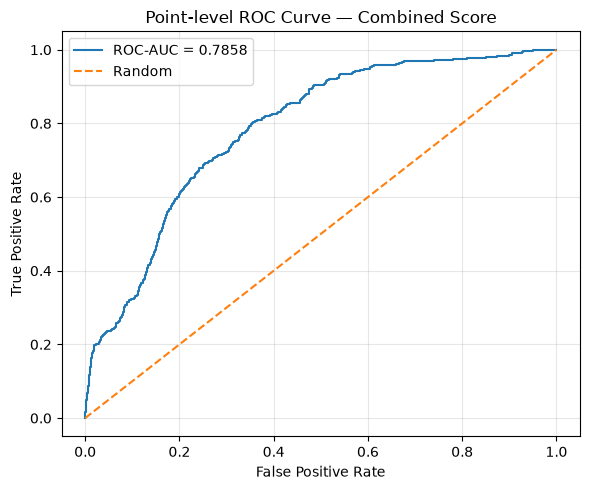

In [149]:
combined_score_point = (
    test_df_eval.loc[
        point_eval_mask,
        endpoint_score_cols["combined"]
    ]
    .astype(float)
    .to_numpy()
)

combined_point_roc_auc = safe_roc_auc(
    y_point,
    combined_score_point
)

if len(np.unique(y_point)) < 2:
    print(
        "ROC curve tidak dapat dibuat "
        "karena hanya ada satu kelas."
    )

else:
    fpr, tpr, _ = roc_curve(
        y_point,
        combined_score_point
    )

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        label=(
            f"ROC-AUC = "
            f"{combined_point_roc_auc:.4f}"
        )
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(
        "Point-level ROC Curve — Combined Score"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

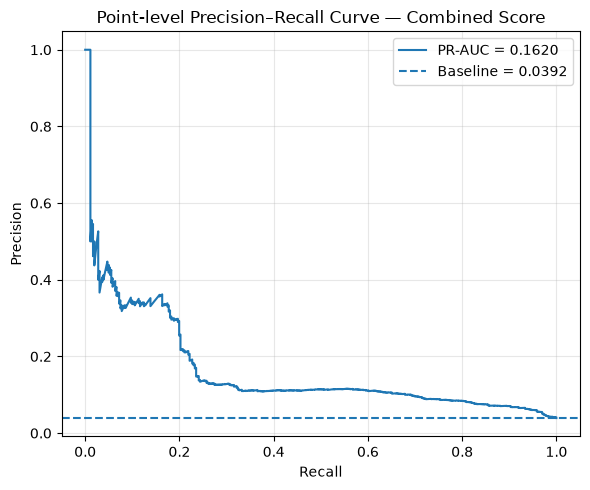

In [150]:
combined_point_pr_auc = safe_point_pr_auc(
    y_point,
    combined_score_point
)

if len(np.unique(y_point)) < 2:
    print(
        "PR curve tidak dapat dibuat "
        "karena hanya ada satu kelas."
    )

else:
    precision, recall, _ = (
        precision_recall_curve(
            y_point,
            combined_score_point
        )
    )

    positive_rate = y_point.mean()

    plt.figure(figsize=(6, 5))

    plt.plot(
        recall,
        precision,
        label=(
            f"PR-AUC = "
            f"{combined_point_pr_auc:.4f}"
        )
    )

    plt.axhline(
        y=positive_rate,
        linestyle="--",
        label=(
            f"Baseline = "
            f"{positive_rate:.4f}"
        )
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(
        "Point-level Precision–Recall Curve "
        "— Combined Score"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

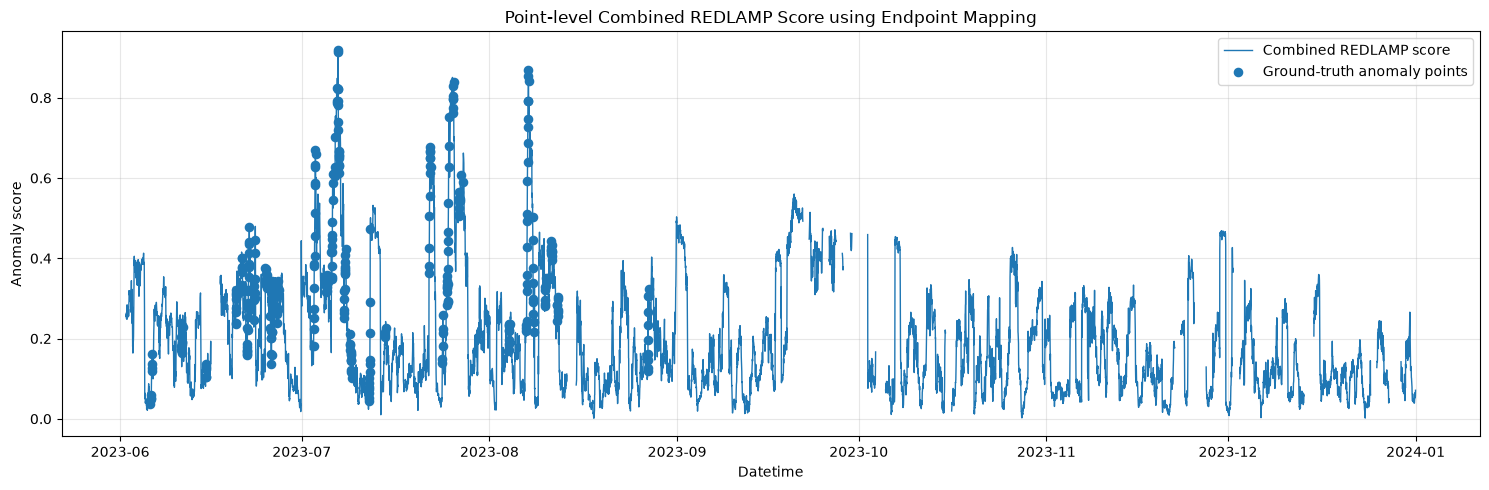

In [151]:
combined_score_col = (
    endpoint_score_cols["combined"]
)

plt.figure(figsize=(15, 5))

plt.plot(
    test_df_eval["datetime"],
    test_df_eval[combined_score_col],
    linewidth=1,
    label="Combined REDLAMP score"
)

anom_points = test_df_eval[
    test_df_eval[label_col]
    .fillna(0)
    .astype(int) == 1
]

plt.scatter(
    anom_points["datetime"],
    anom_points[combined_score_col],
    s=35,
    zorder=3,
    label="Ground-truth anomaly points"
)

plt.title(
    "Point-level Combined REDLAMP Score "
    "using Endpoint Mapping"
)
plt.xlabel("Datetime")
plt.ylabel("Anomaly score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()